<a href="https://www.kaggle.com/code/lalit7881/e-commerce-customer-segmentation-75-43?scriptVersionId=347204500" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/datascikhan/e-commerce-customer-segmentation-2026/E-commerce_Customer_Segmentation_2026.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/datascikhan/e-commerce-customer-segmentation-2026/E-commerce_Customer_Segmentation_2026.csv")

In [3]:
df.head()

,customer_id,customer_segment,segment_category,age,age_group,gender,country,city,income_bracket,education_level,...,customer_value_category,activity_status,health_status,churn_risk_category,rfm_category,profitability_category,engagement_level,behavior_segment,device_preference,clv_category
0,CUST-000001,Consumer,High Value Inactive,70,65+,Male,Canada,Winnipeg,150K+,Professional,...,High,Dormant,Excellent,Low,Potential Loyalists,High Profit,Low,Regular Buyer,Multi-Device,High CLV
1,CUST-000002,Premium,High Value Inactive,53,45-54,Female,Germany,Essen,25K-50K,High School,...,Medium,Inactive,Excellent,Medium,At Risk,High Profit,Low,Occasional Buyer,Desktop-First,High CLV
2,CUST-000003,Consumer,High Value Inactive,82,65+,Male,Mexico,Puebla,75K-100K,Bachelors,...,Very High,Dormant,Excellent,Very Low,Champions,High Profit,Low,Regular Buyer,Multi-Device,High CLV
3,CUST-000004,Enterprise,High Value Active,18,18-24,Male,Singapore,Singapore,150K+,Masters,...,Very High,Active,Excellent,Very Low,Champions,High Profit,High,Frequent Buyer,Mobile-First,High CLV
4,CUST-000005,Premium,High Value Active,64,55-64,Male,United Arab Emirates,Fujairah,150K+,PhD,...,Medium,Active,Fair,Medium,Loyal,High Profit,Medium,Occasional Buyer,Desktop-First,High CLV


In [4]:
df.tail()

,customer_id,customer_segment,segment_category,age,age_group,gender,country,city,income_bracket,education_level,...,customer_value_category,activity_status,health_status,churn_risk_category,rfm_category,profitability_category,engagement_level,behavior_segment,device_preference,clv_category
49995,CUST-049996,Small Business,Low Value,22,18-24,Female,United States,San Antonio,50K-75K,PhD,...,Very Low,Inactive,Fair,High,Need Attention,High Profit,Low,Occasional Buyer,Multi-Device,Low CLV
49996,CUST-049997,Small Business,High Value Inactive,24,18-24,Male,Brazil,Rio de Janeiro,25K-50K,PhD,...,Very High,Dormant,Excellent,Low,Champions,High Profit,Medium,Regular Buyer,Multi-Device,High CLV
49997,CUST-049998,Consumer,High Value Inactive,29,25-34,Female,France,Strasbourg,100K-150K,Bachelors,...,Very High,Dormant,Excellent,Very Low,Champions,High Profit,Low,Regular Buyer,Multi-Device,High CLV
49998,CUST-049999,Consumer,High Value Active,74,65+,Male,Italy,Catania,100K-150K,Bachelors,...,High,Active,Good,Low,Champions,High Profit,Low,Frequent Buyer,Multi-Device,High CLV
49999,CUST-050000,Consumer,High Value Inactive,77,65+,Female,United Arab Emirates,Sharjah,75K-100K,Masters,...,Very High,Inactive,Excellent,Low,Loyal,High Profit,Low,Occasional Buyer,Desktop-First,High CLV


In [5]:
df.info(
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 53 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   customer_id                    50000 non-null  object 
 1   customer_segment               50000 non-null  object 
 2   segment_category               50000 non-null  object 
 3   age                            50000 non-null  int64  
 4   age_group                      50000 non-null  object 
 5   gender                         50000 non-null  object 
 6   country                        50000 non-null  object 
 7   city                           50000 non-null  object 
 8   income_bracket                 50000 non-null  object 
 9   education_level                50000 non-null  object 
 10  employment_type                50000 non-null  object 
 11  marital_status                 50000 non-null  object 
 12  tenure_months                  50000 non-null 

In [6]:
df.describe()

,age,tenure_months,total_purchases,avg_order_value_usd,total_spent_usd,days_since_last_purchase,return_count,complaint_count,satisfaction_score,email_open_rate,...,customer_lifetime_value_usd,customer_acquisition_cost_usd,customer_profitability_usd,recency_score,frequency_score,monetary_score,rfm_score,churn_risk_score,customer_health_score,dataset_year
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.0
mean,45.64802,59.748240,99.418460,505.366911,50266.546156,62.971240,9.511740,6.99380,3.007960,0.500319,...,57722.068910,102.453505,57619.615405,3.954040,4.122720,3.717700,11.794460,26.84122,86.674100,2026.0
std,18.36795,34.310128,57.780178,285.604037,44071.209164,93.281404,5.782592,4.32425,1.417976,0.289515,...,52437.283546,56.373987,52437.172654,1.478949,1.077573,1.358633,2.680507,19.20729,16.107113,0.0
min,18.00000,1.000000,0.000000,10.050000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000,...,0.000000,5.010000,-199.870000,1.000000,1.000000,1.000000,3.000000,0.00000,30.000000,2026.0
25%,30.00000,30.000000,49.000000,259.067500,13893.577500,2.000000,4.000000,3.00000,2.000000,0.251000,...,15488.650000,53.820000,15372.800000,3.000000,3.000000,3.000000,10.000000,10.00000,75.000000,2026.0
50%,45.00000,60.000000,99.000000,504.790000,37541.625000,19.000000,10.000000,7.00000,3.000000,0.500000,...,42236.310000,102.320000,42129.690000,5.000000,4.000000,4.000000,12.000000,25.00000,95.000000,2026.0
75%,60.00000,90.000000,150.000000,752.702500,76811.242500,77.000000,15.000000,11.00000,4.000000,0.752000,...,86714.875000,151.260000,86608.330000,5.000000,5.000000,5.000000,14.000000,40.00000,100.000000,2026.0
max,84.00000,119.000000,199.000000,999.990000,198574.140000,365.000000,19.000000,14.00000,5.000000,1.000000,...,294634.150000,200.000000,294479.720000,5.000000,5.000000,5.000000,15.000000,100.00000,100.000000,2026.0


In [7]:
df.isnull().sum()

customer_id                          0
customer_segment                     0
segment_category                     0
age                                  0
age_group                            0
gender                               0
country                              0
city                                 0
income_bracket                       0
education_level                      0
employment_type                      0
marital_status                       0
tenure_months                        0
total_purchases                      0
avg_order_value_usd                  0
total_spent_usd                      0
purchase_frequency                   0
days_since_last_purchase             0
preferred_category_1                 0
preferred_category_2             16743
preferred_category_3             33257
shopping_channel                     0
device_used                          0
payment_method                       0
return_count                         0
complaint_count          

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

customer_id                       object
customer_segment                  object
segment_category                  object
age                                int64
age_group                         object
gender                            object
country                           object
city                              object
income_bracket                    object
education_level                   object
employment_type                   object
marital_status                    object
tenure_months                      int64
total_purchases                    int64
avg_order_value_usd              float64
total_spent_usd                  float64
purchase_frequency                object
days_since_last_purchase           int64
preferred_category_1              object
preferred_category_2              object
preferred_category_3              object
shopping_channel                  object
device_used                       object
payment_method                    object
return_count    

In [10]:
df.shape

(50000, 53)

In [11]:
df.columns

Index(['customer_id', 'customer_segment', 'segment_category', 'age',
       'age_group', 'gender', 'country', 'city', 'income_bracket',
       'education_level', 'employment_type', 'marital_status', 'tenure_months',
       'total_purchases', 'avg_order_value_usd', 'total_spent_usd',
       'purchase_frequency', 'days_since_last_purchase',
       'preferred_category_1', 'preferred_category_2', 'preferred_category_3',
       'shopping_channel', 'device_used', 'payment_method', 'return_count',
       'complaint_count', 'satisfaction_score', 'satisfaction_level',
       'loyalty_tier', 'email_open_rate', 'click_through_rate',
       'conversion_rate', 'social_media_presence',
       'customer_lifetime_value_usd', 'customer_acquisition_cost_usd',
       'customer_profitability_usd', 'recency_score', 'frequency_score',
       'monetary_score', 'rfm_score', 'churn_risk_score',
       'customer_health_score', 'dataset_year', 'customer_value_category',
       'activity_status', 'health_status',

In [12]:
df.nunique()

customer_id                      50000
customer_segment                     4
segment_category                     6
age                                 67
age_group                            6
gender                               2
country                             17
city                               157
income_bracket                       6
education_level                      5
employment_type                      5
marital_status                       4
tenure_months                      119
total_purchases                    200
avg_order_value_usd              39370
total_spent_usd                  49334
purchase_frequency                   5
days_since_last_purchase           366
preferred_category_1                12
preferred_category_2                12
preferred_category_3                12
shopping_channel                     4
device_used                          4
payment_method                       5
return_count                        20
complaint_count          

## EDA


MISSING VALUES
purchase_frequency       50000
social_media_presence    50000
preferred_category_3     33257
preferred_category_2     16743
loyalty_tier              1272
dtype: int64

DATA TYPES
customer_id                       object
customer_segment                  object
segment_category                  object
age                                int64
age_group                         object
gender                            object
country                           object
city                              object
income_bracket                    object
education_level                   object
employment_type                   object
marital_status                    object
tenure_months                      int64
total_purchases                    int64
avg_order_value_usd              float64
total_spent_usd                  float64
purchase_frequency               float64
days_since_last_purchase           int64
preferred_category_1              object
preferred_category_2     

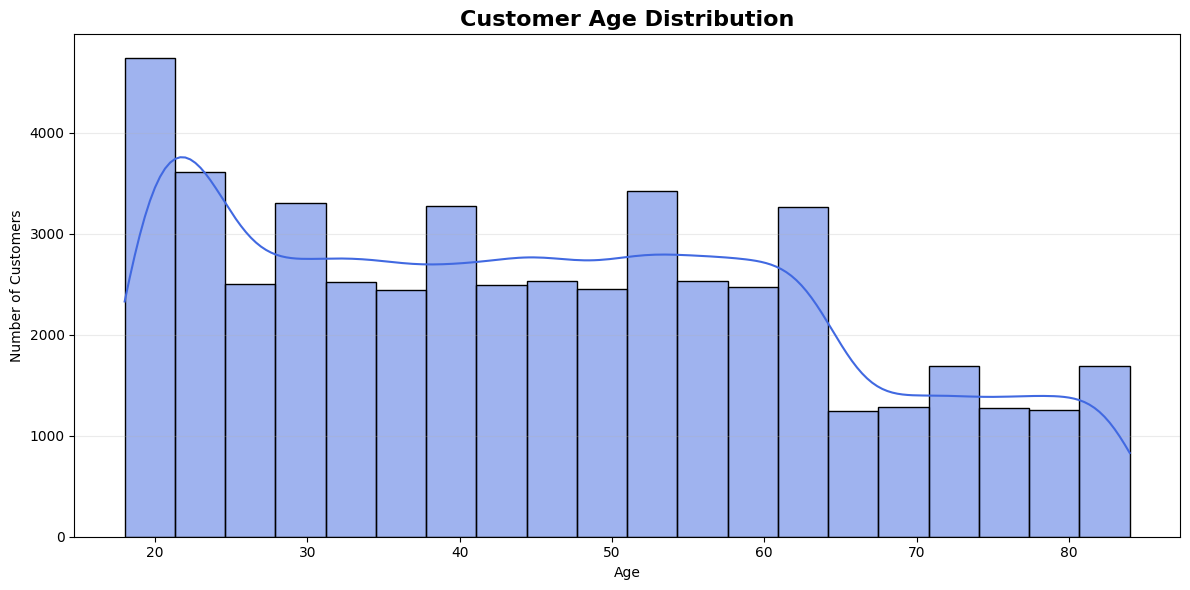

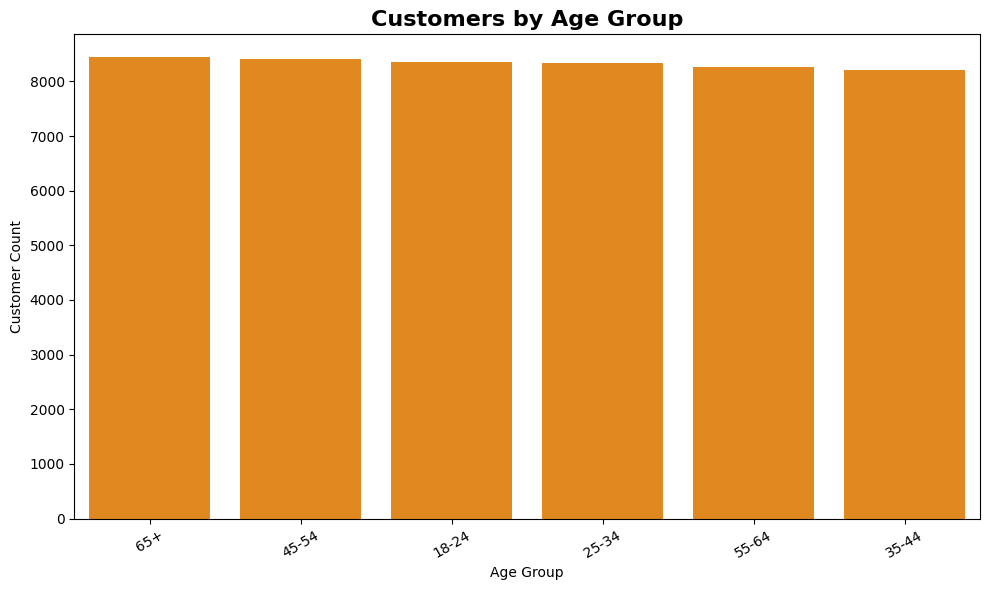

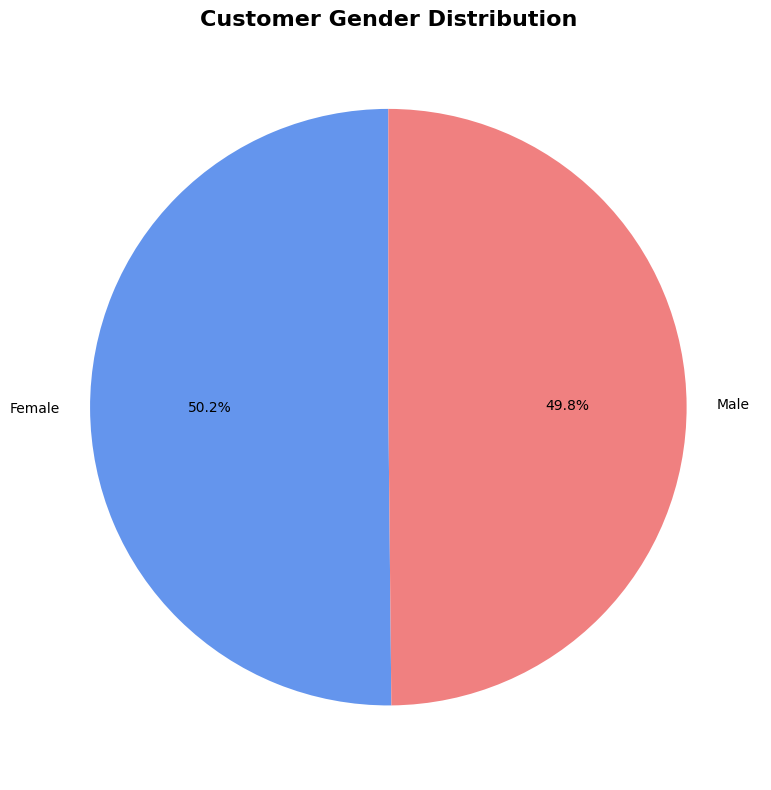

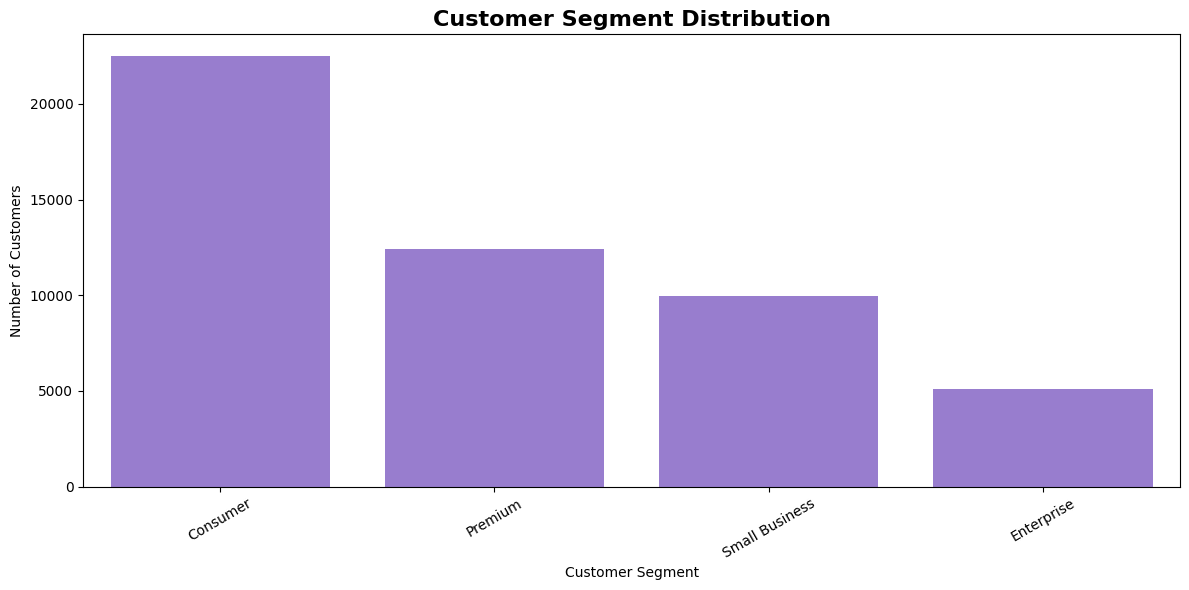

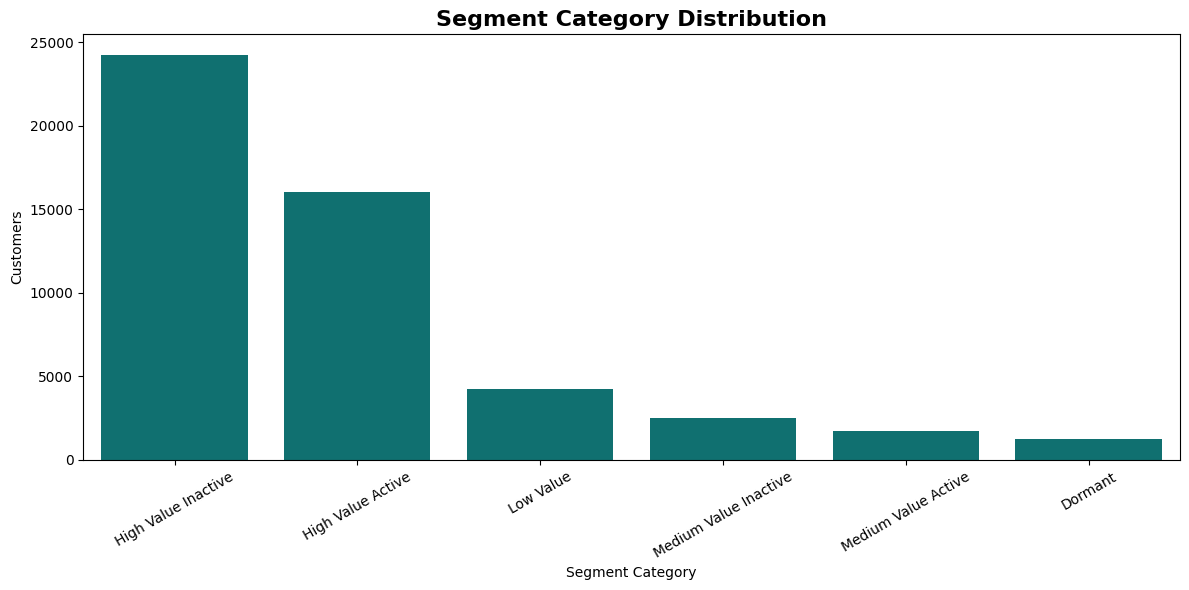

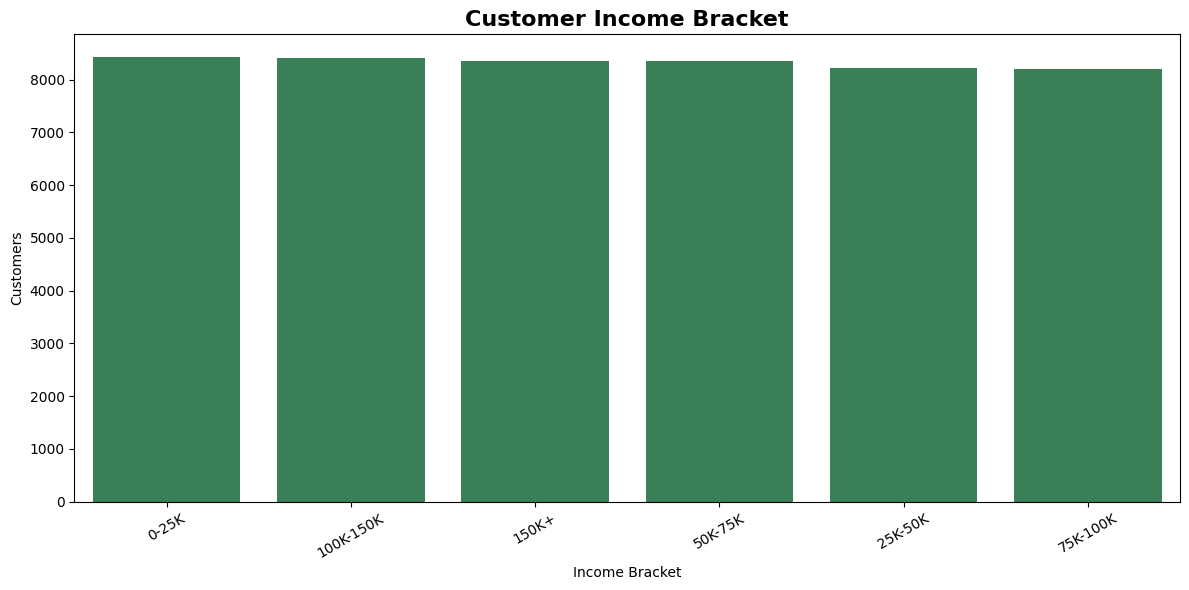

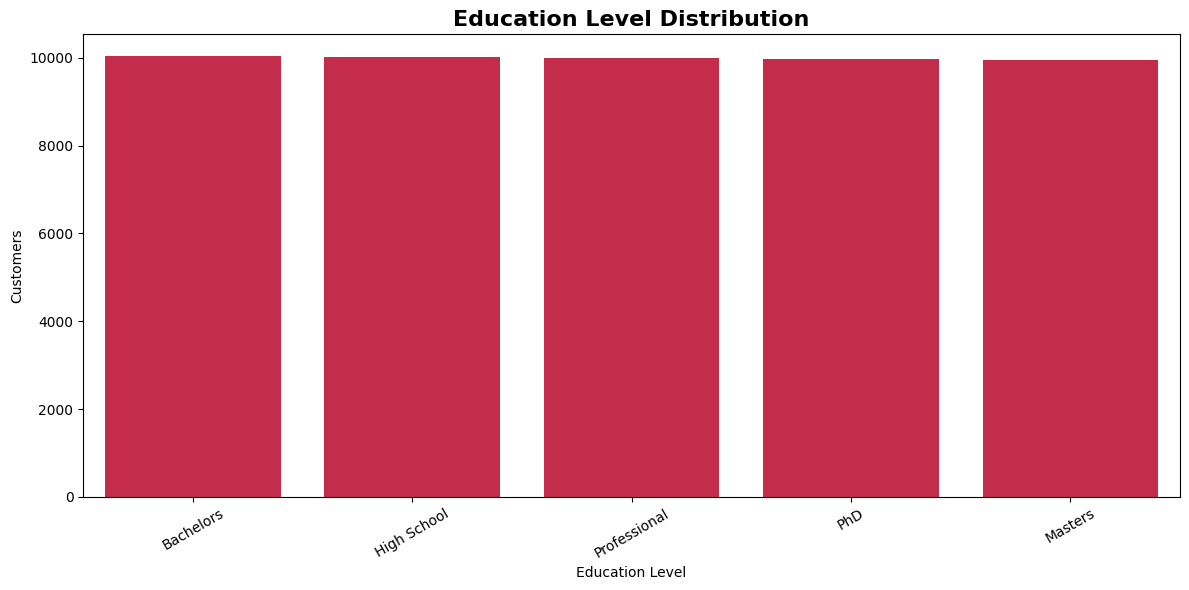

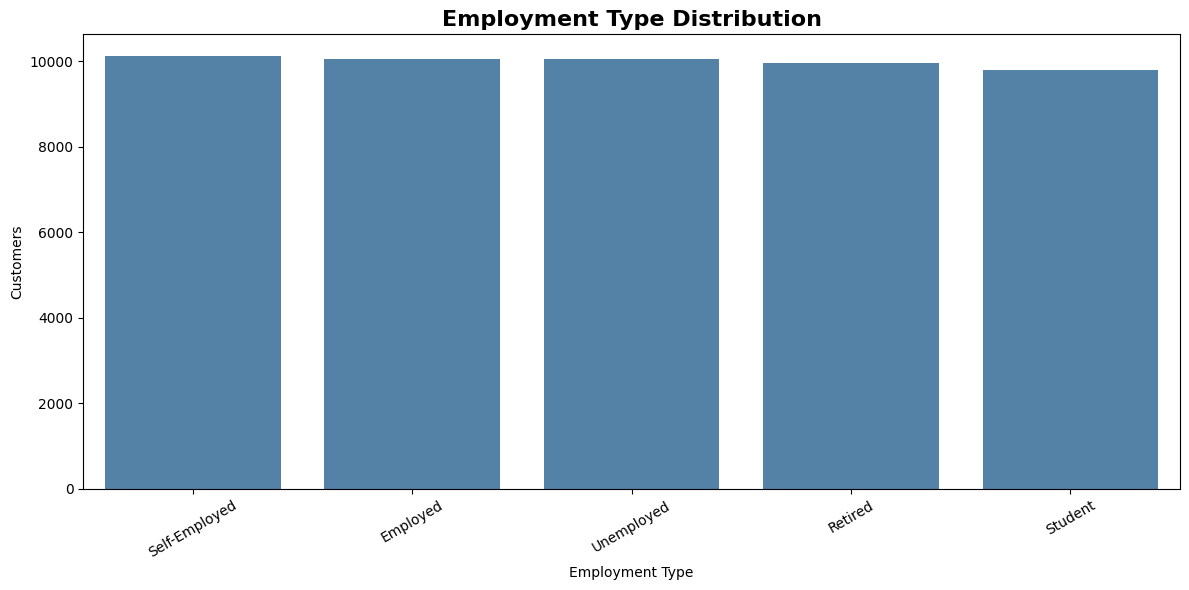

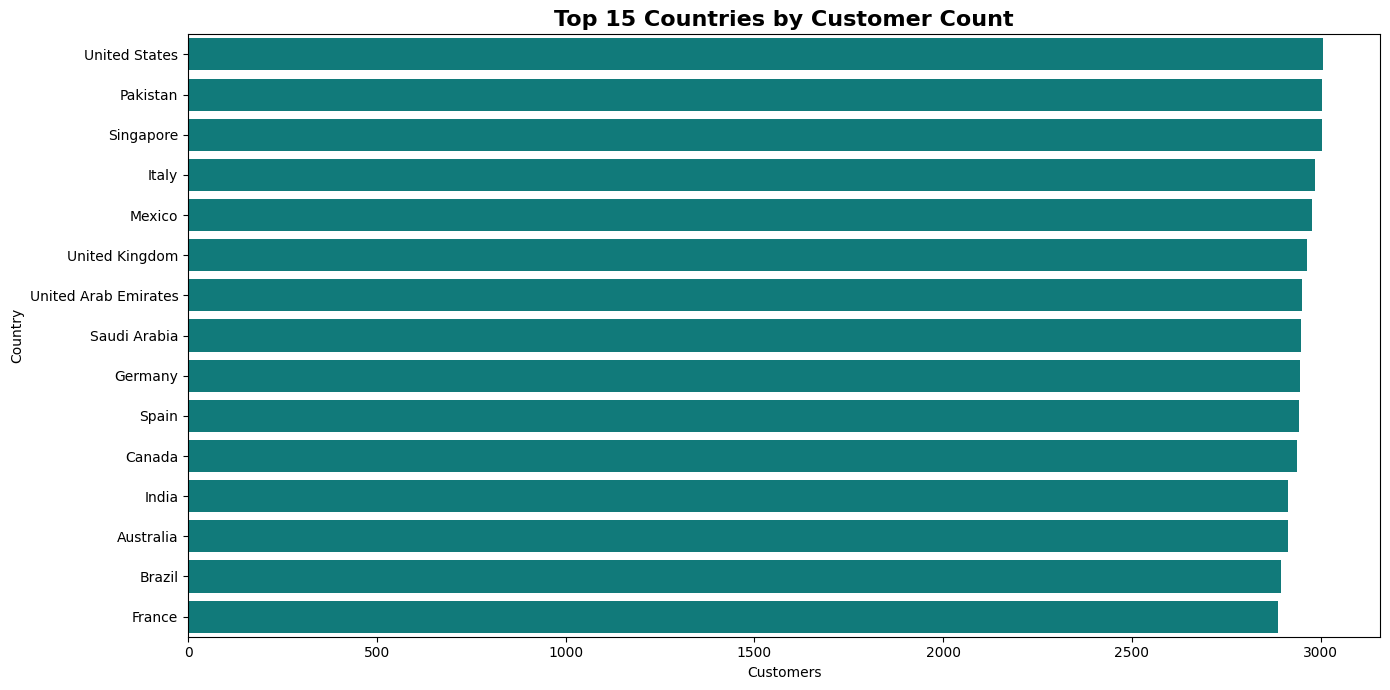

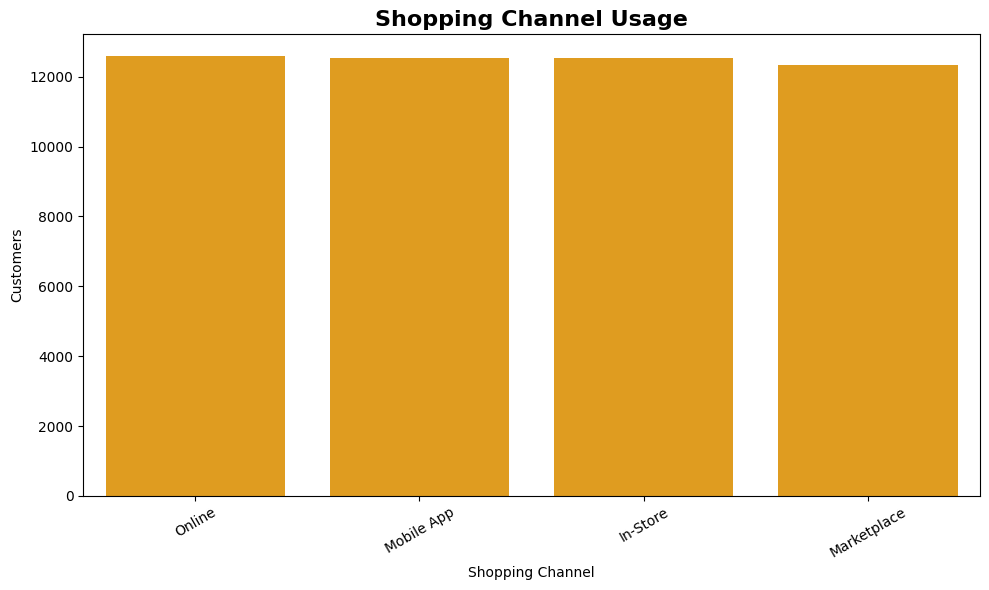

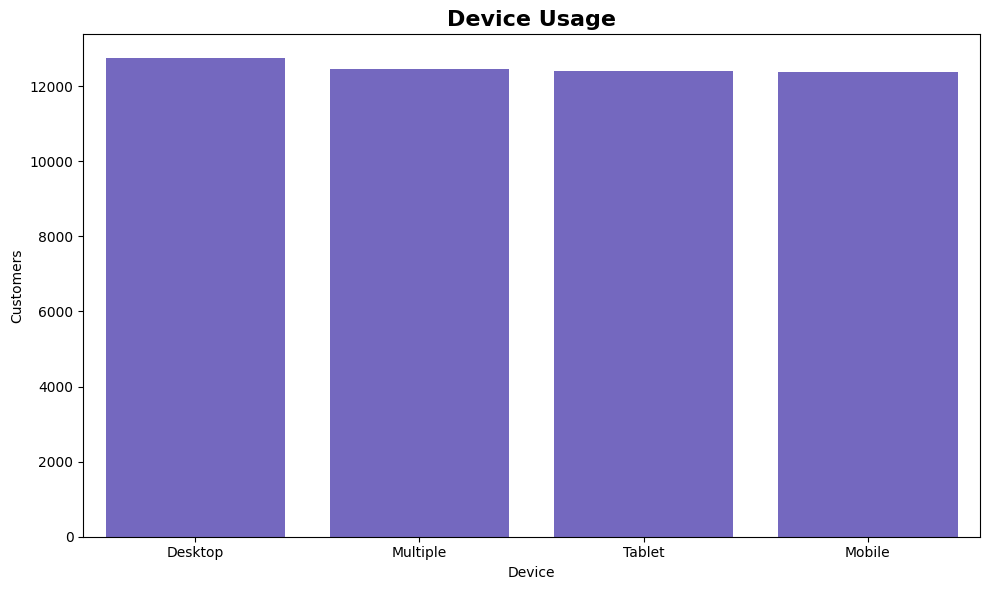

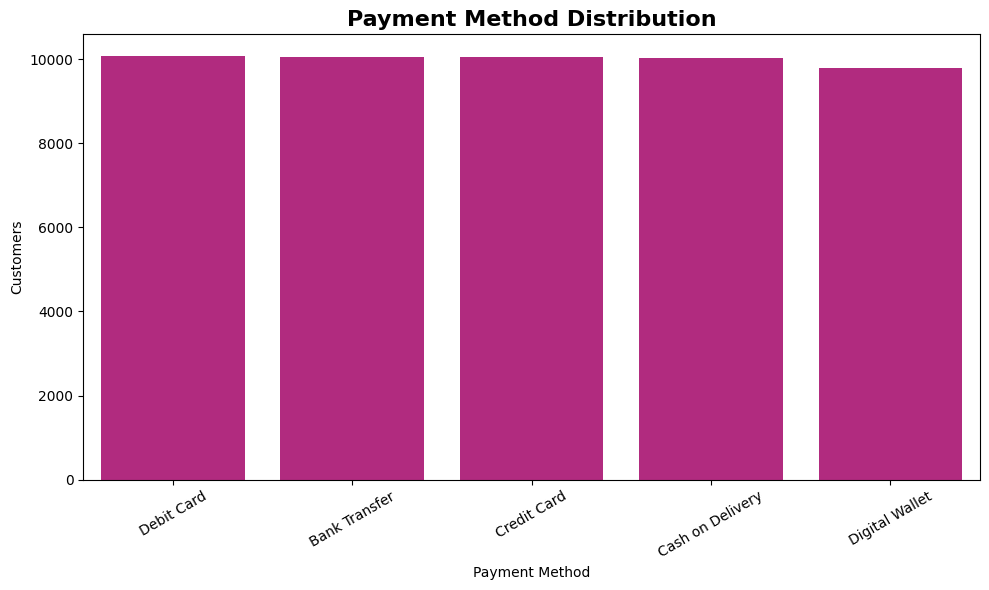

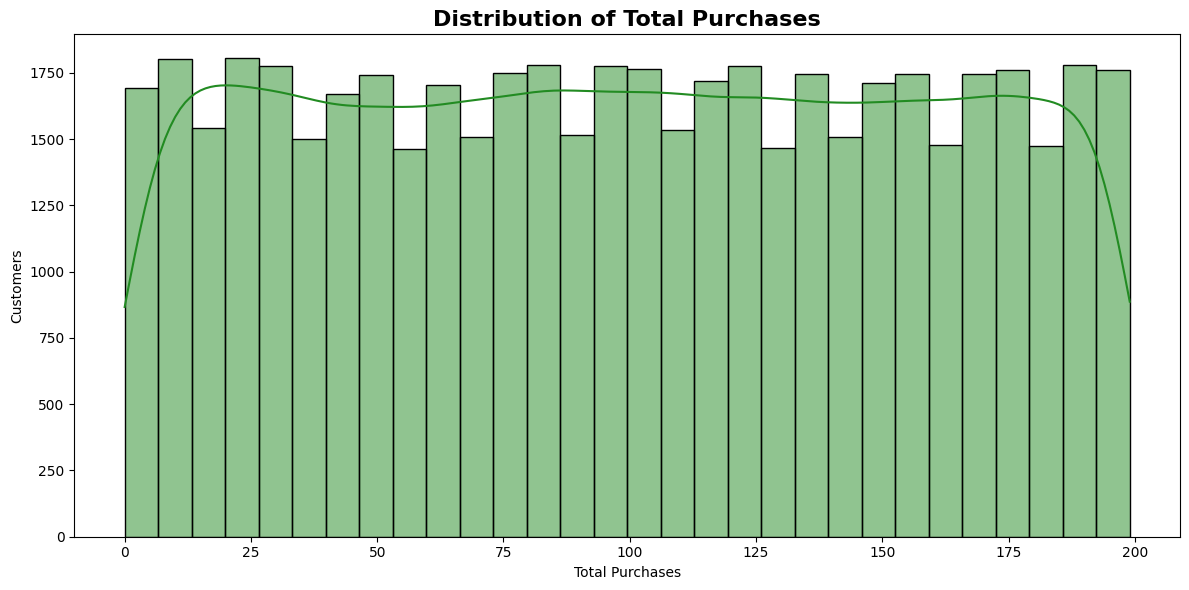

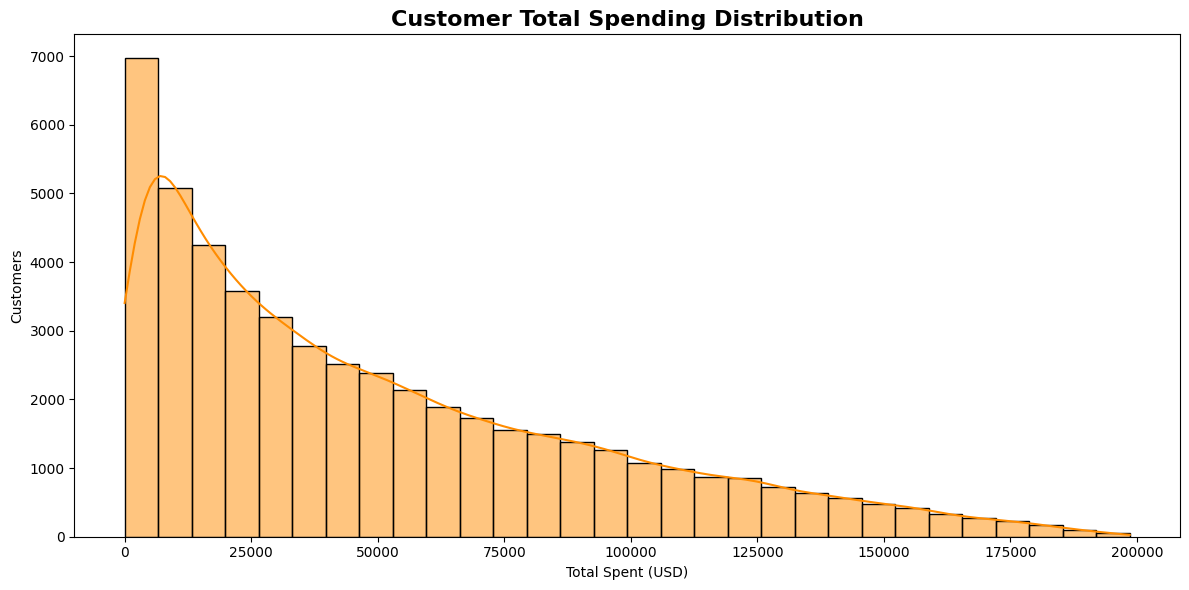

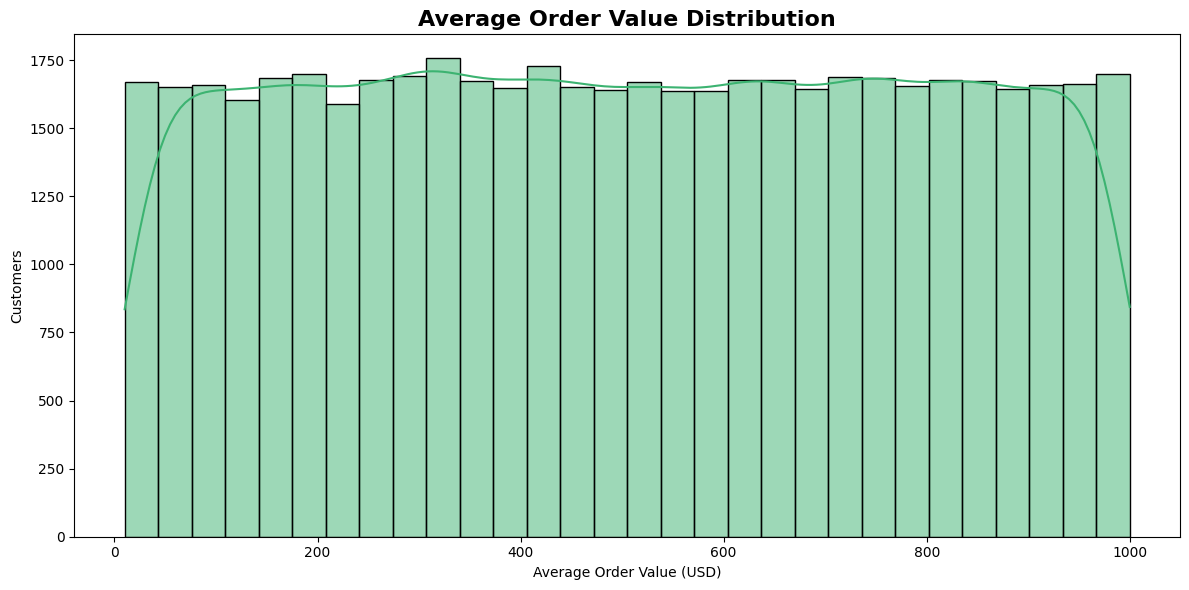

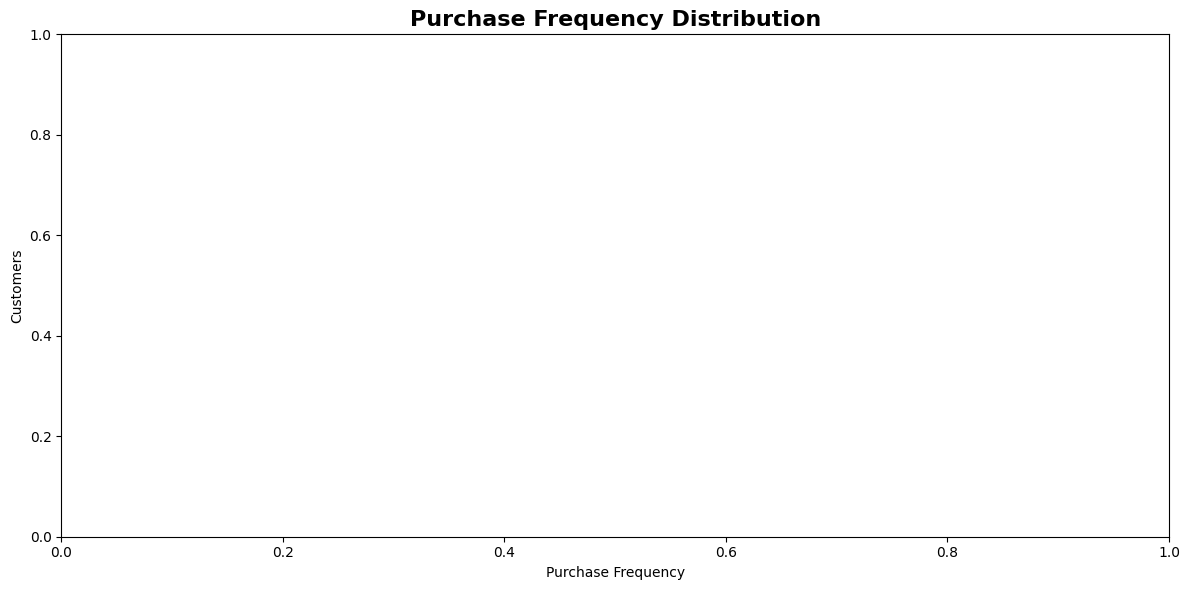

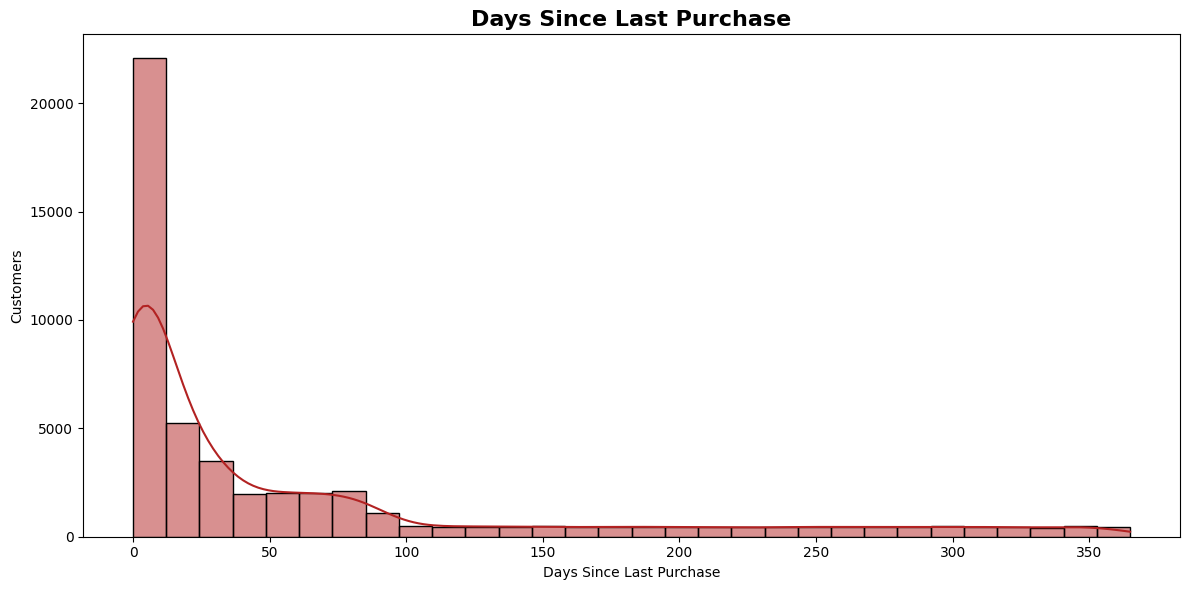

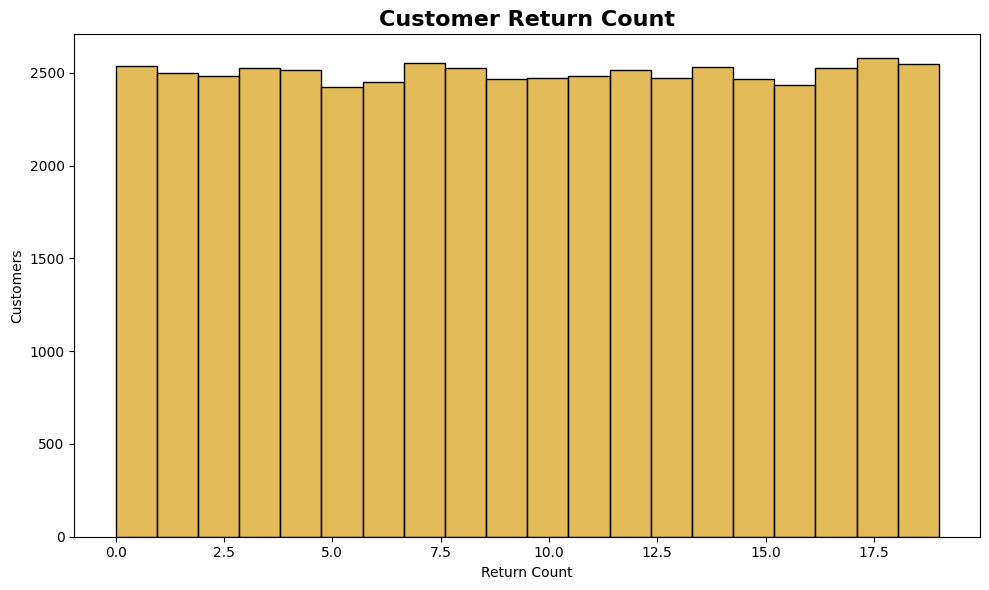

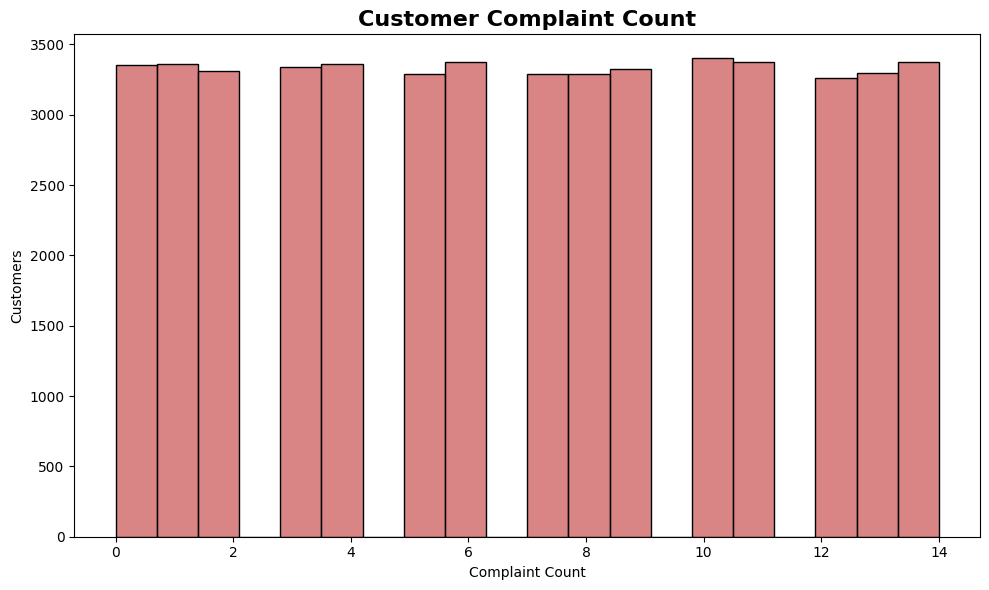

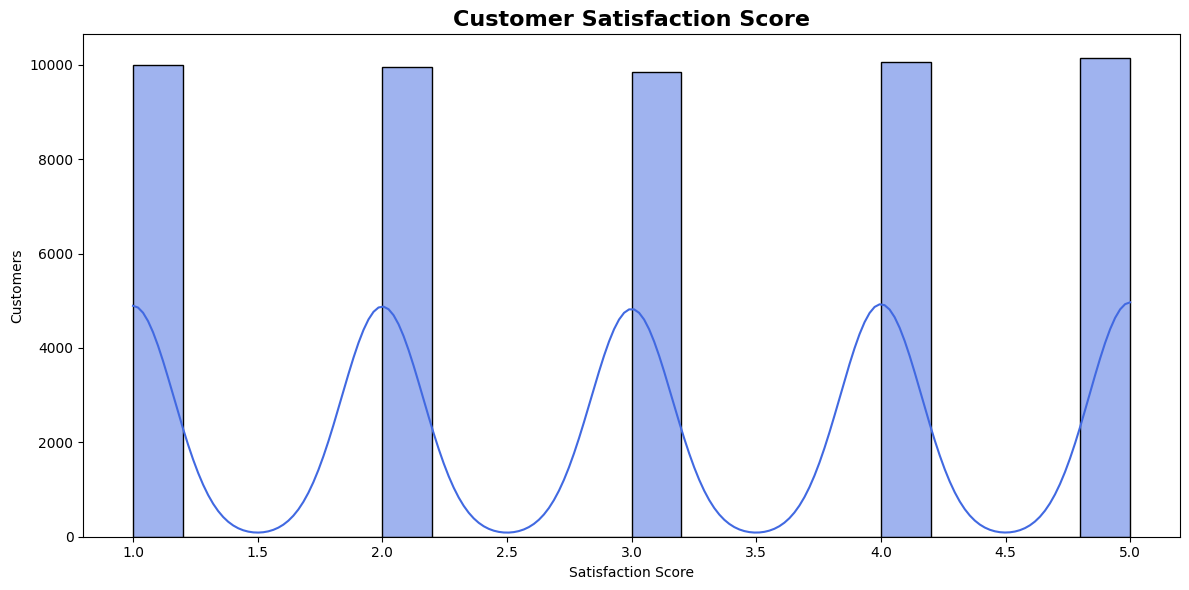

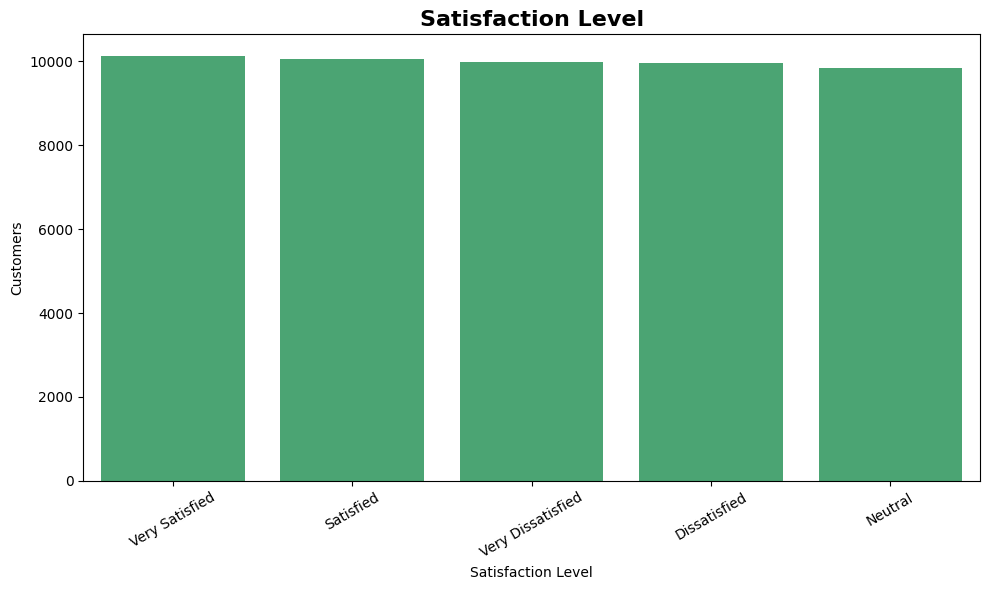

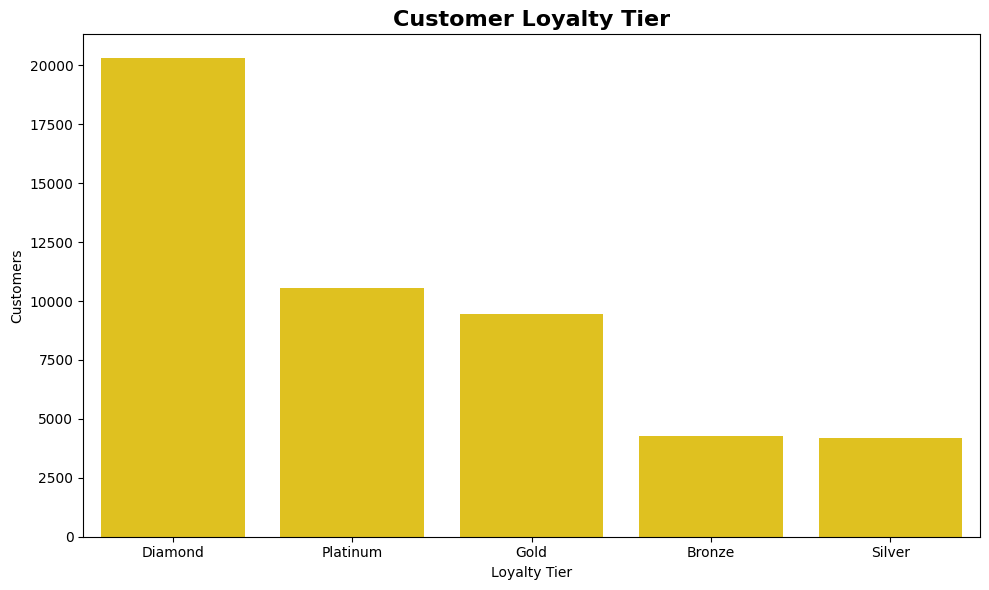

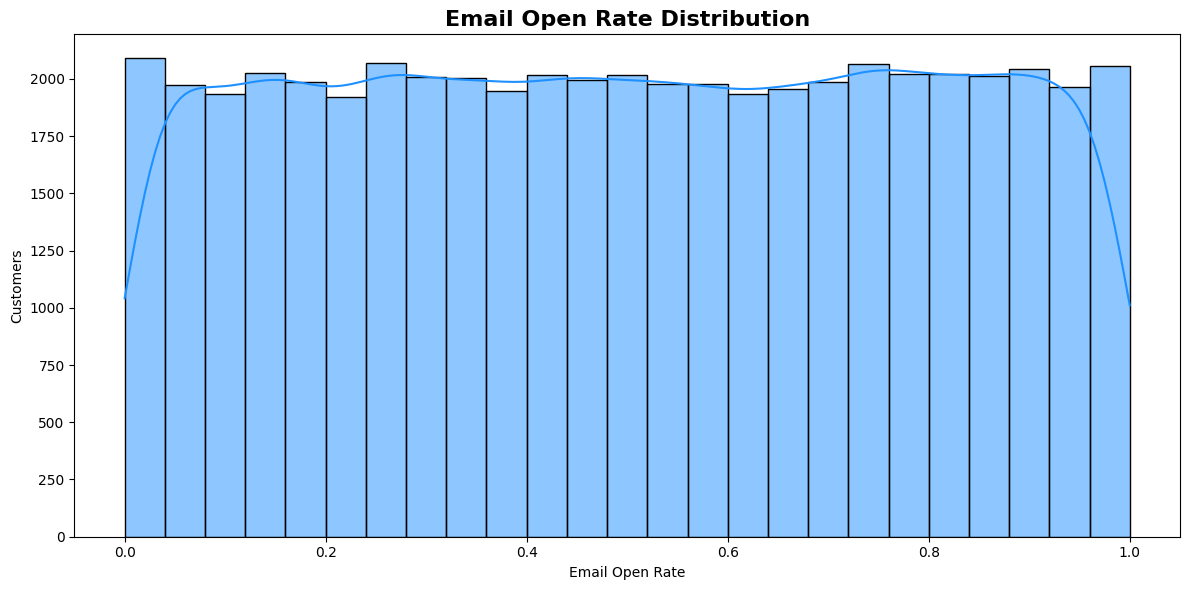

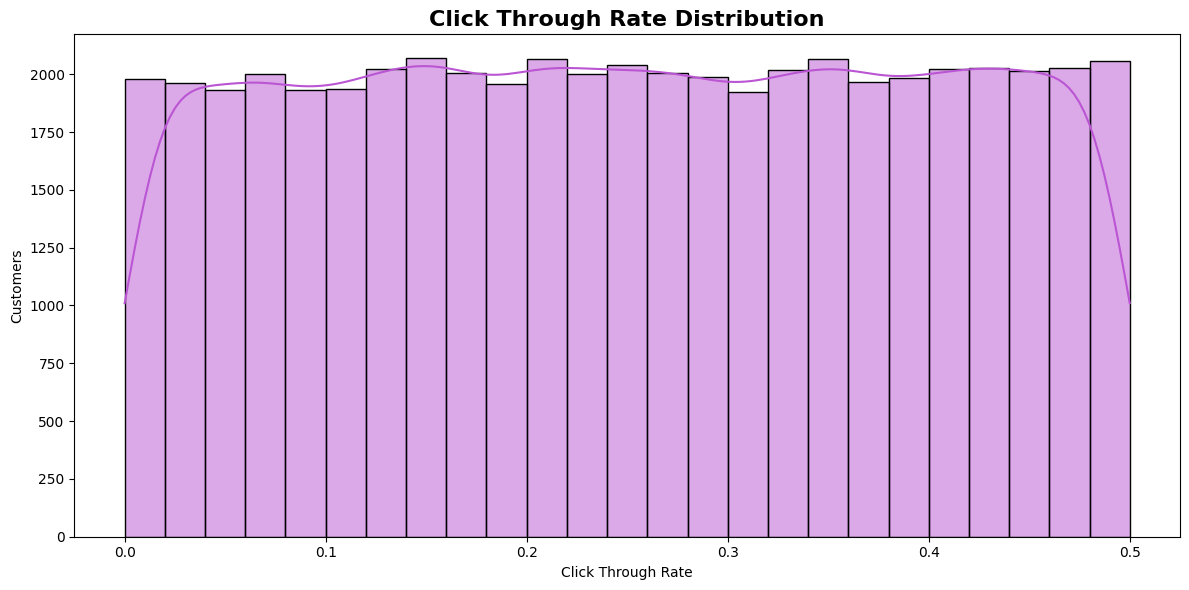

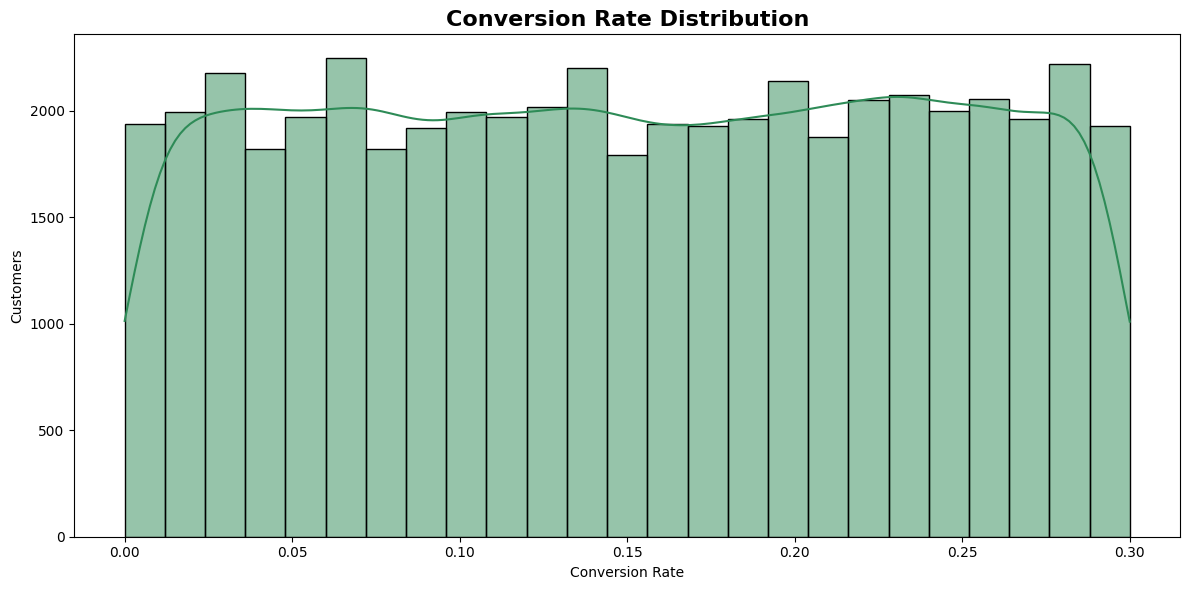

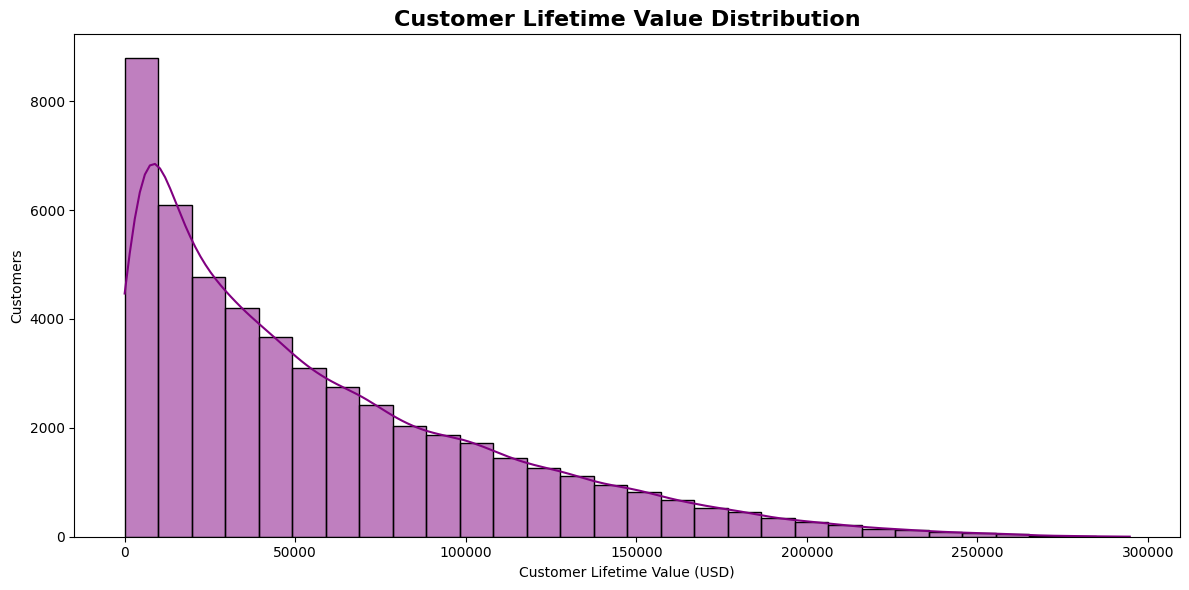

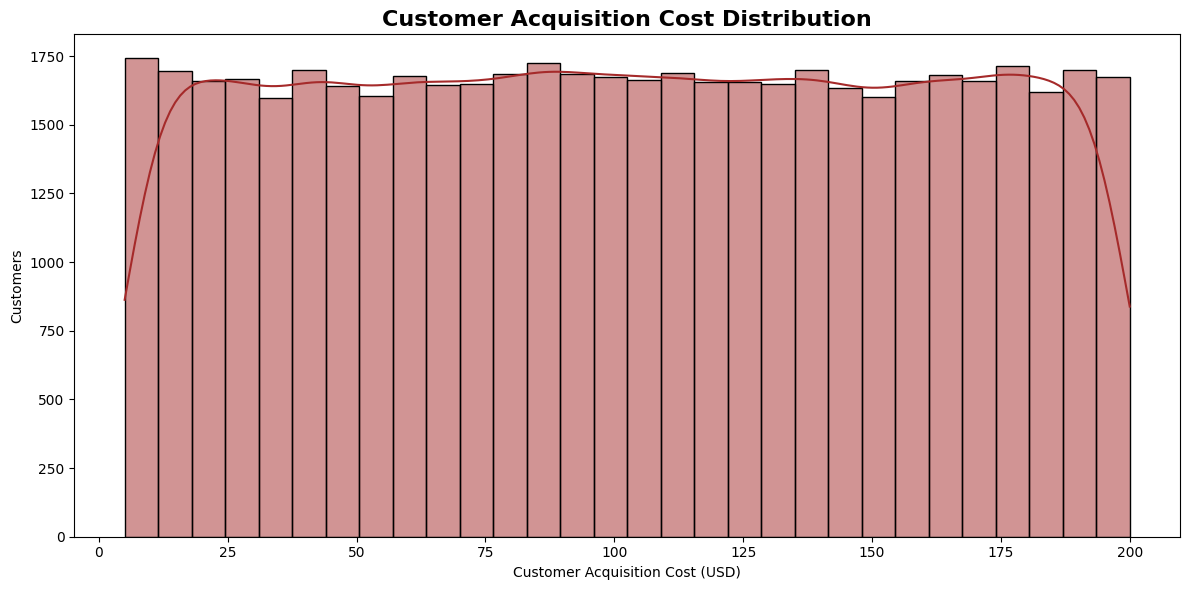

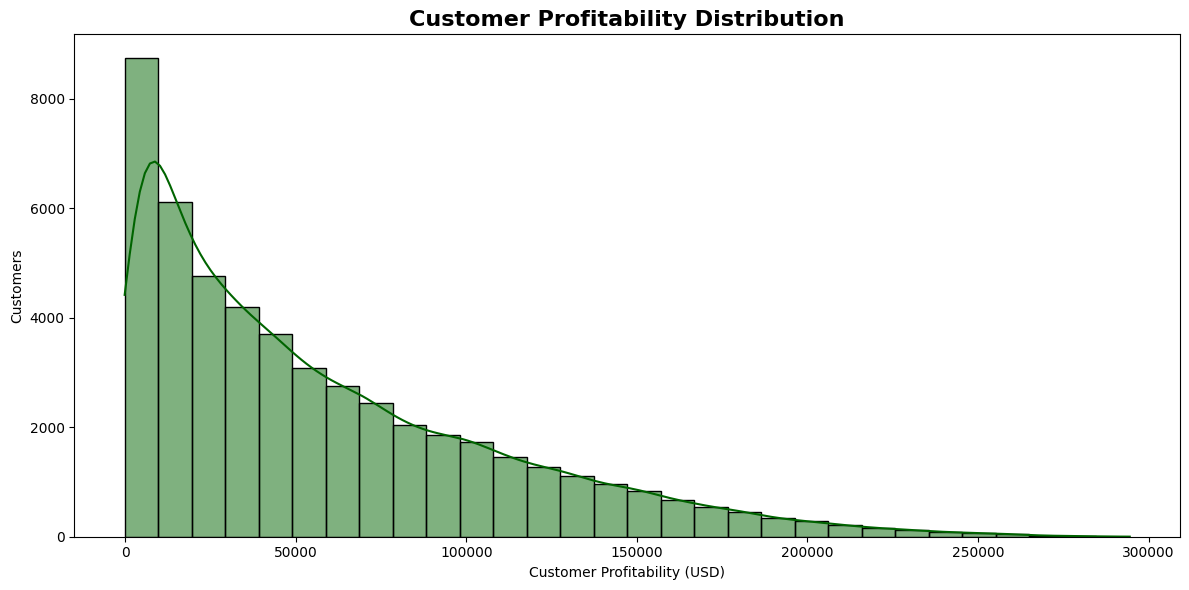

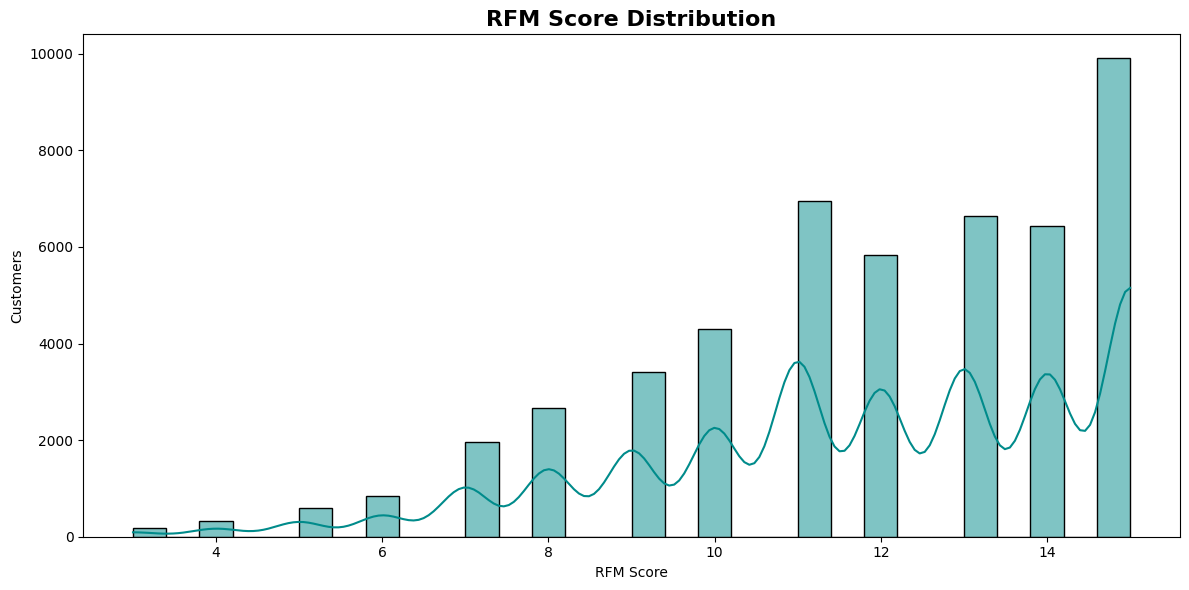

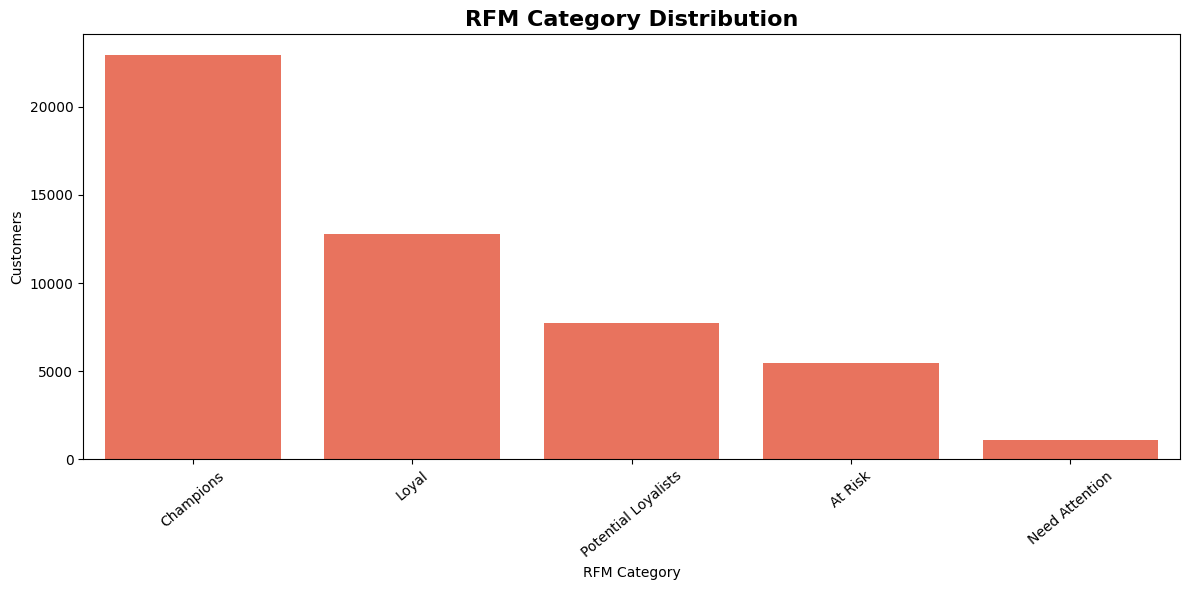

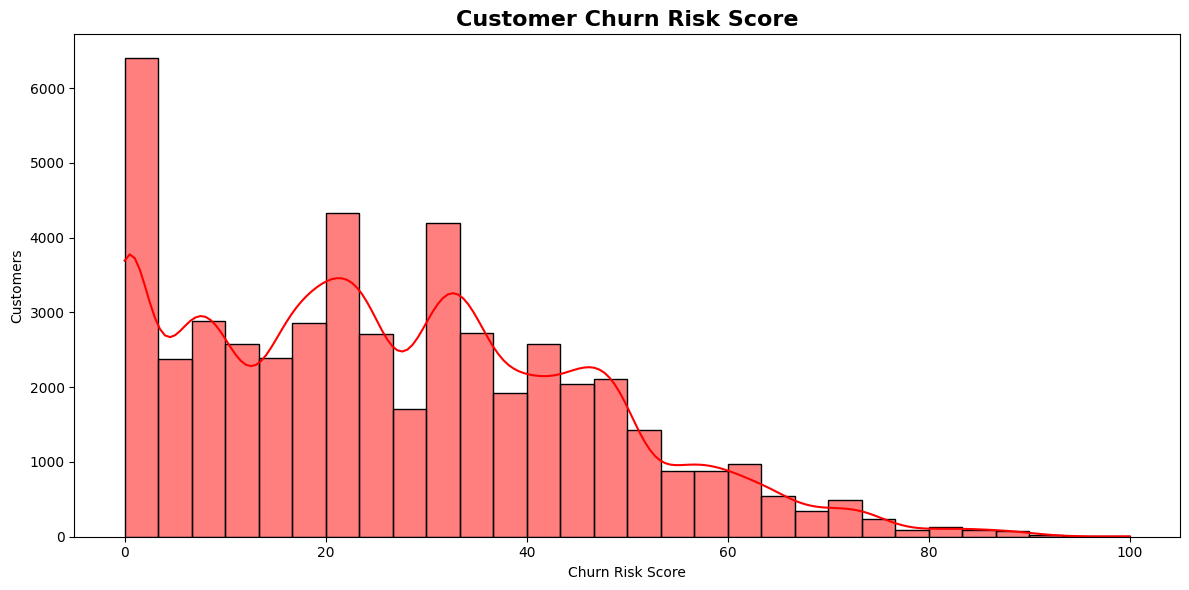

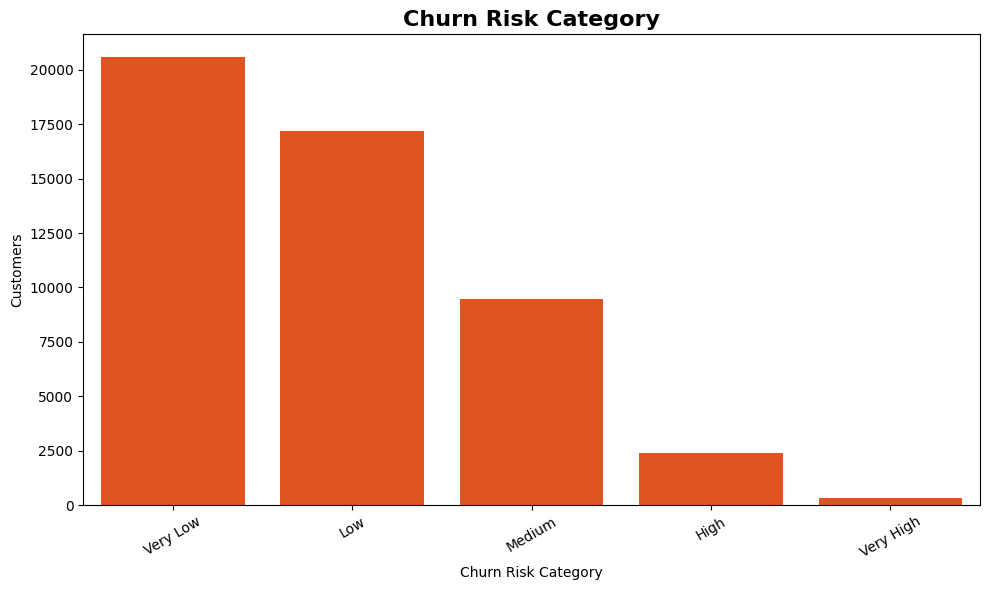

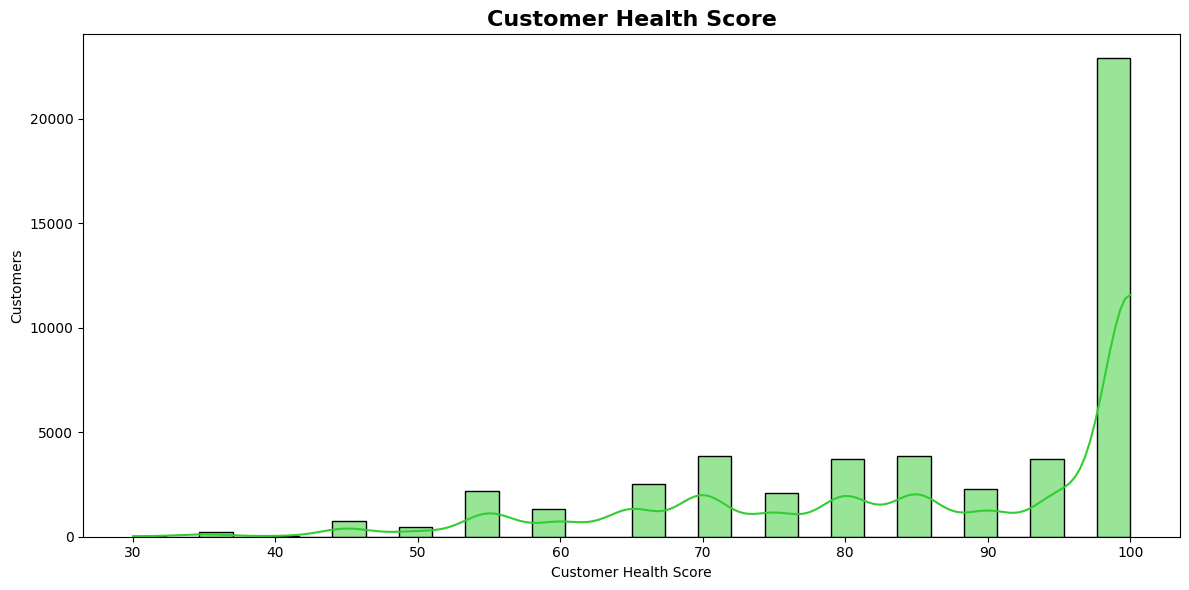

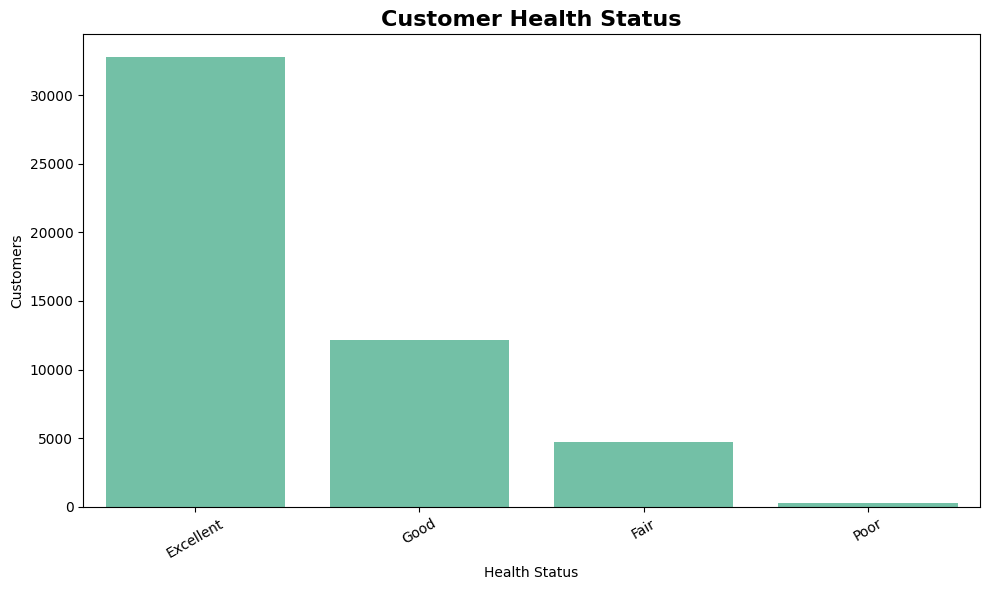

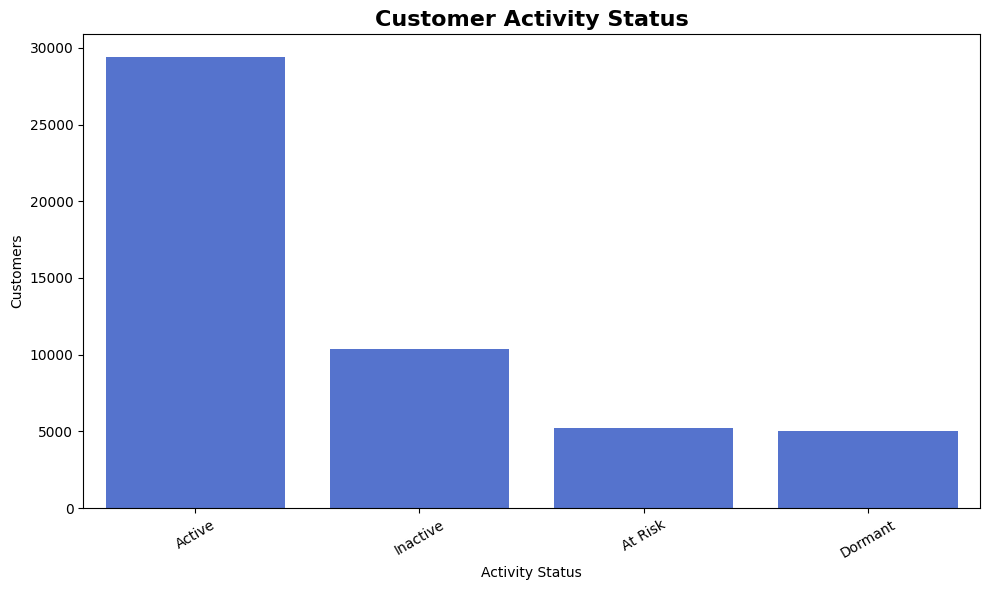

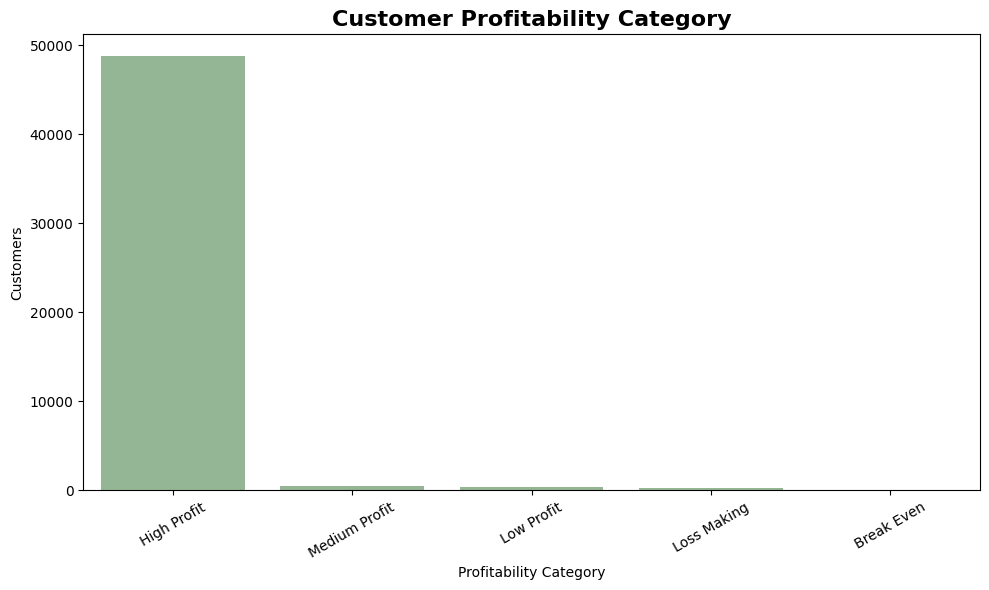

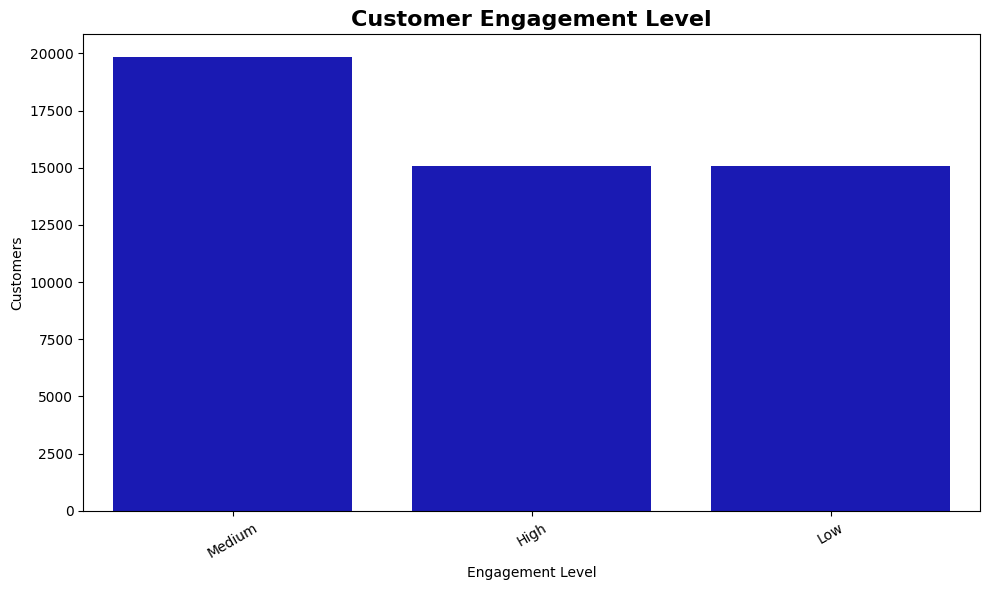

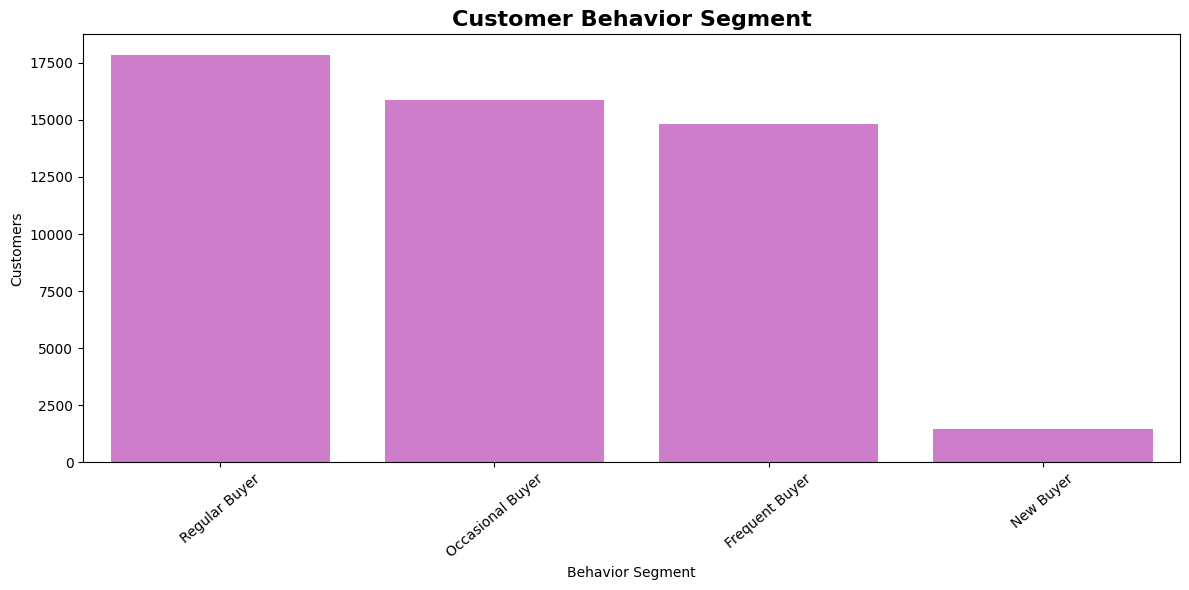

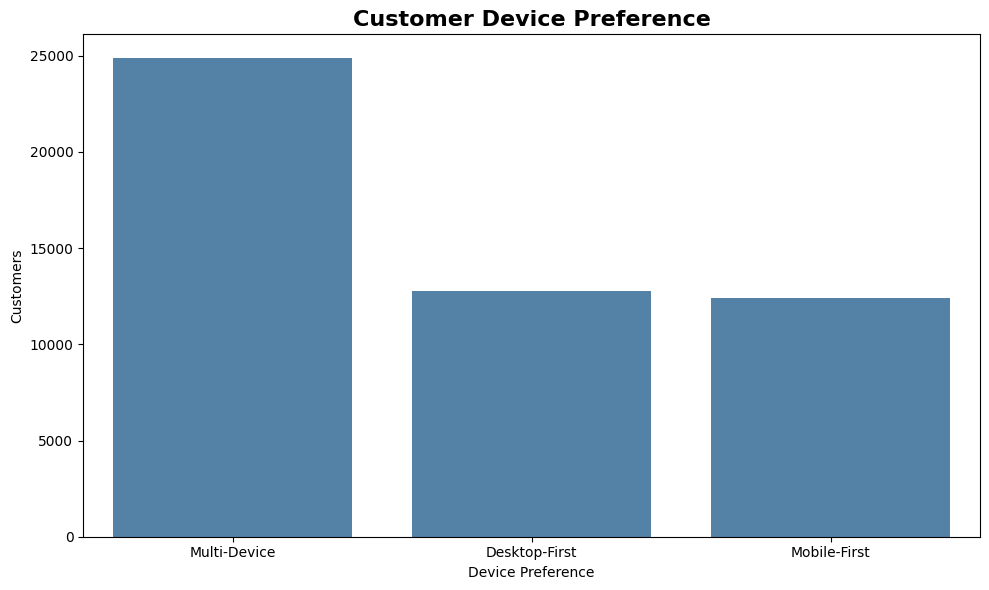

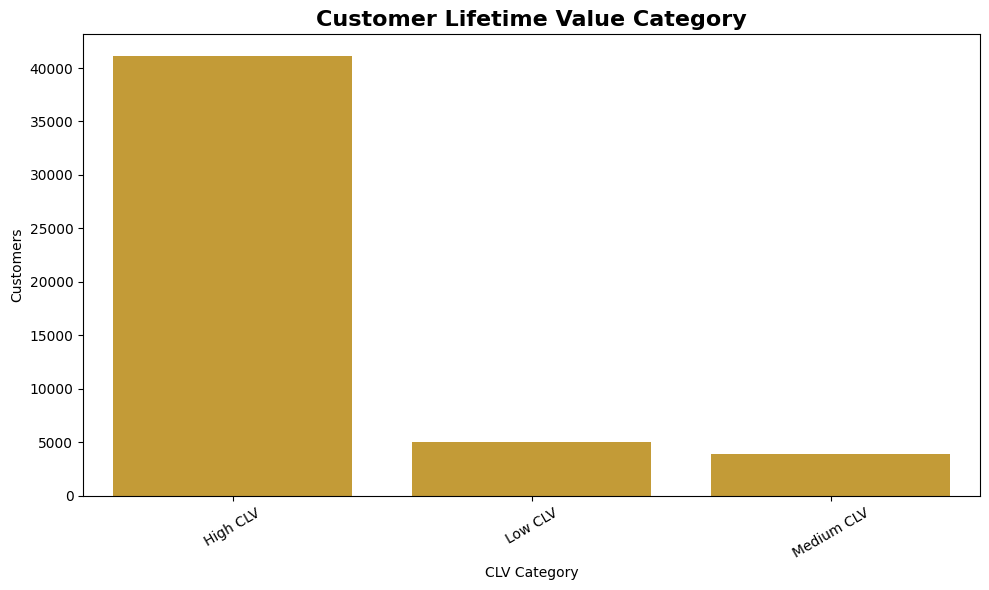

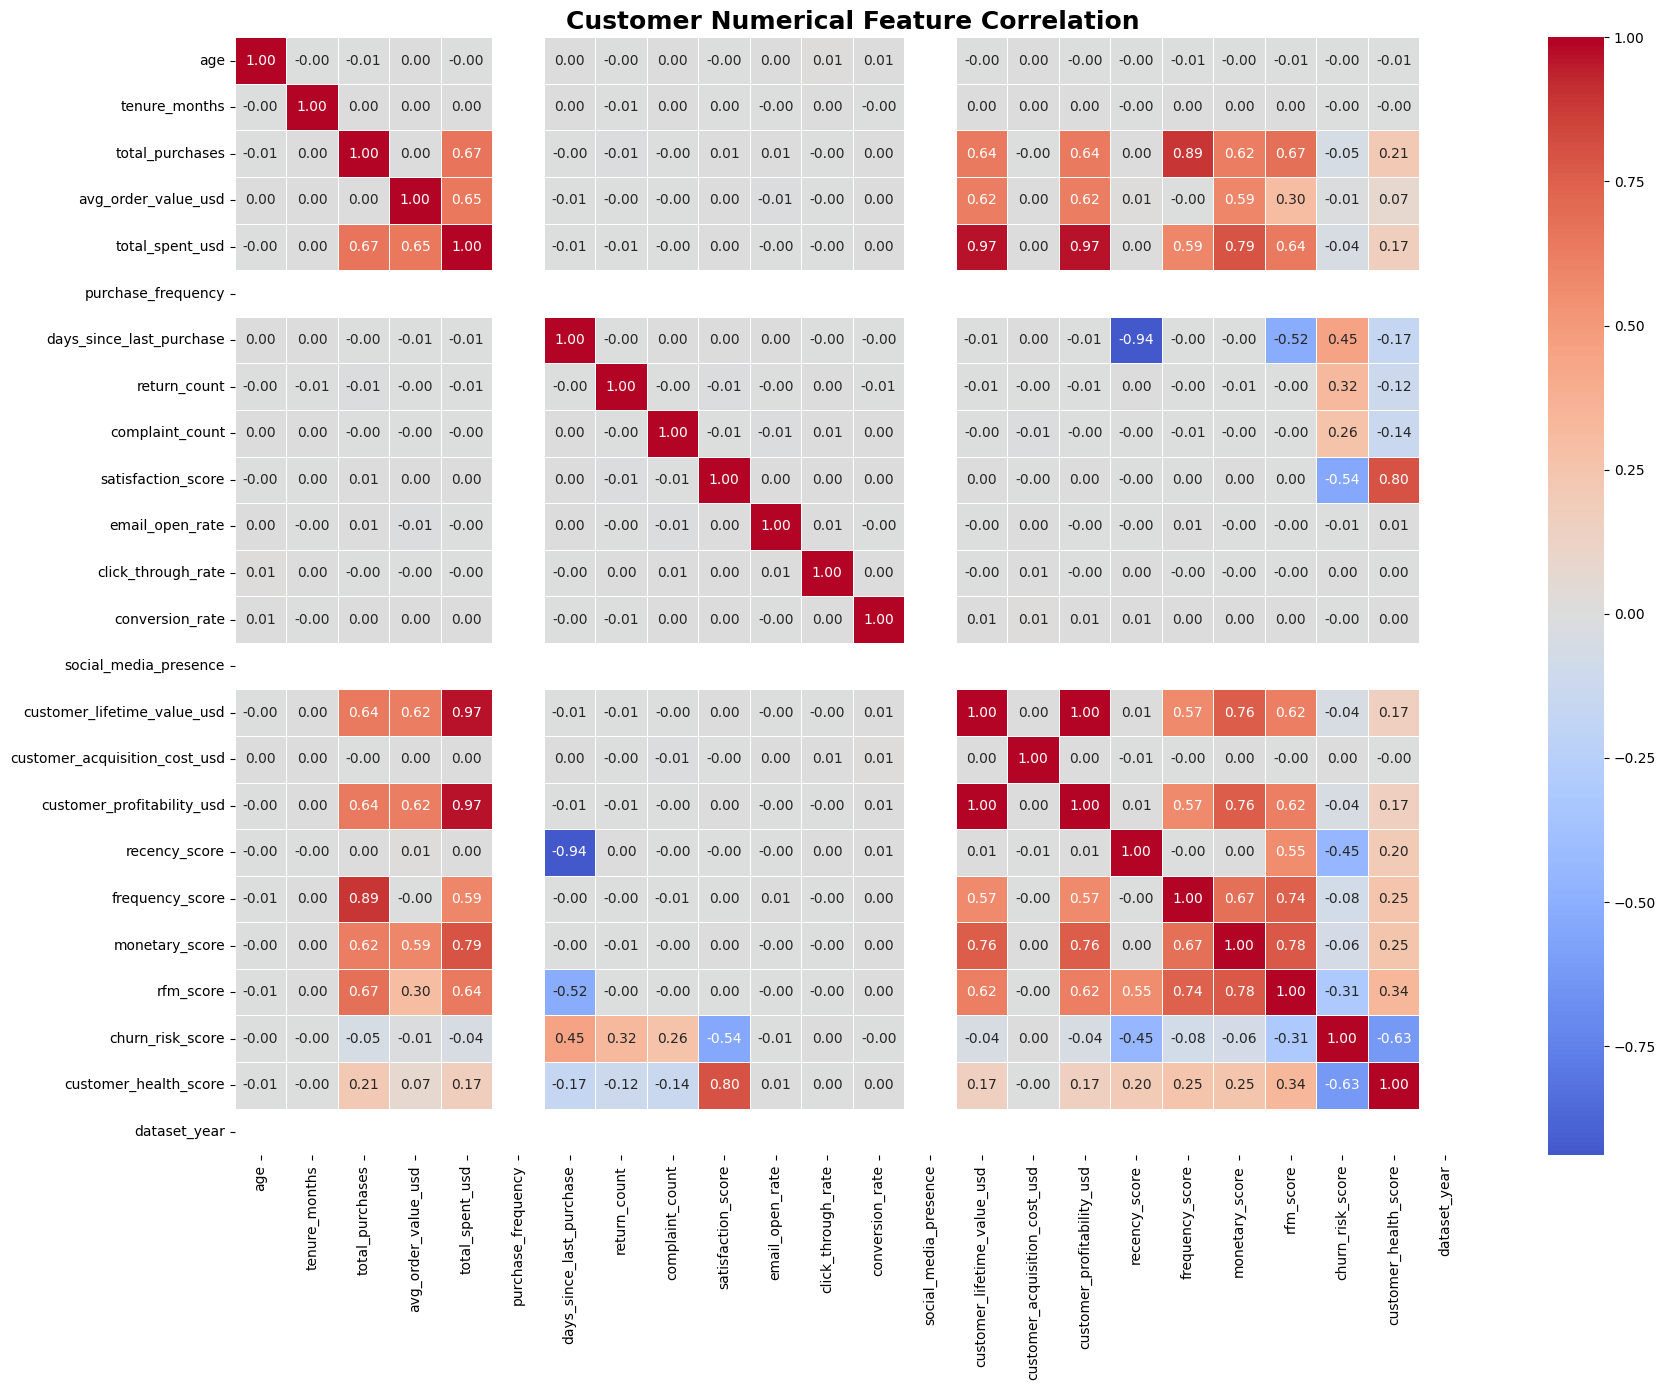

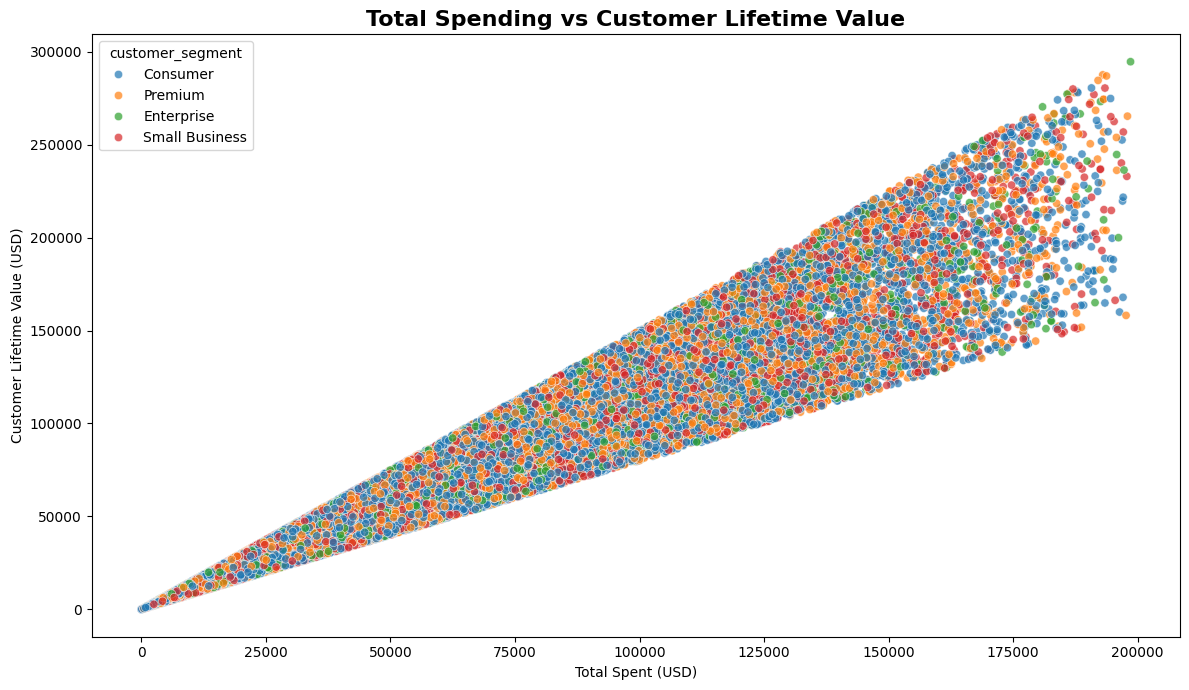

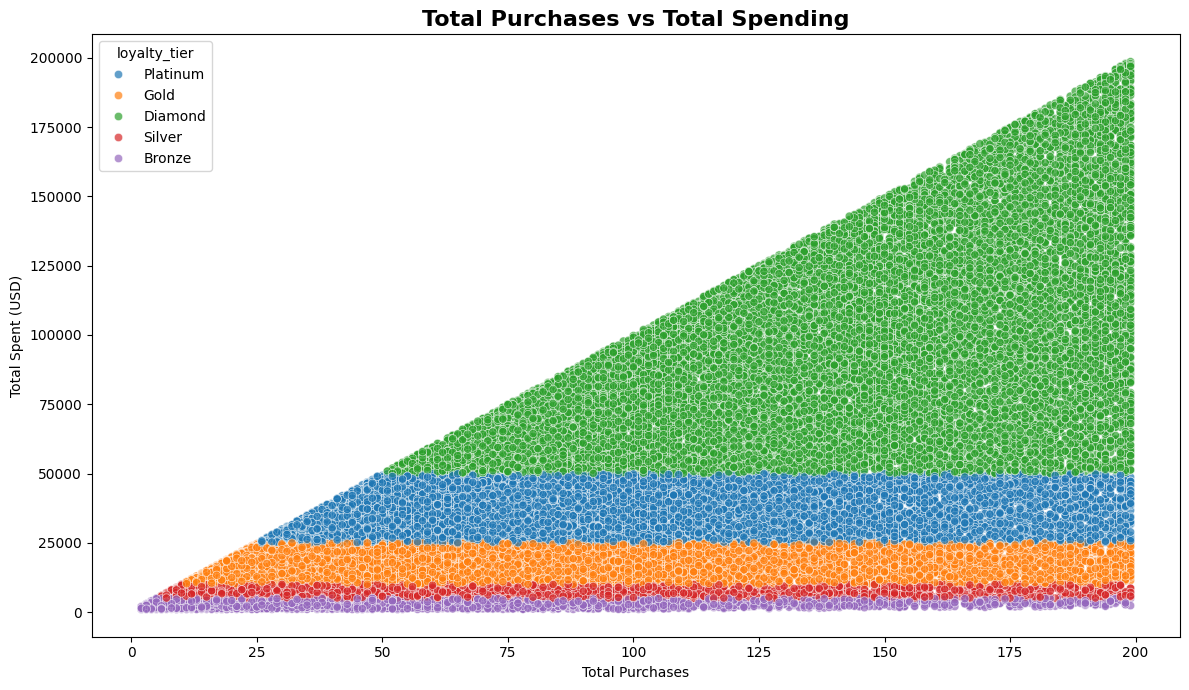

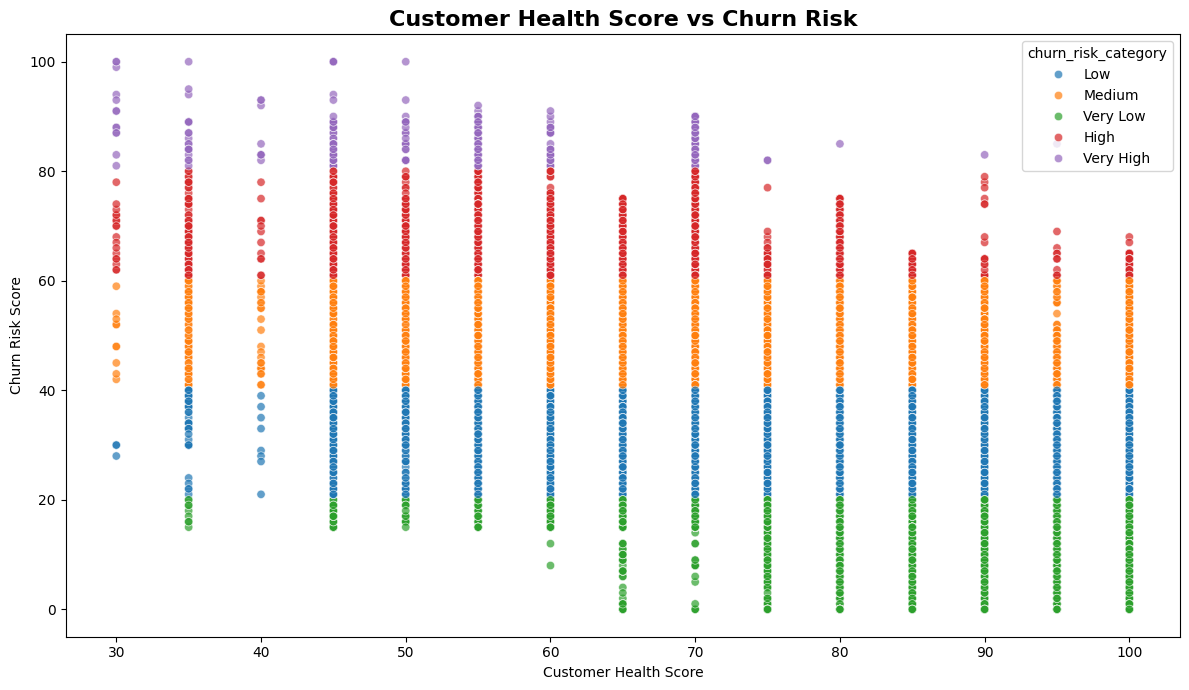

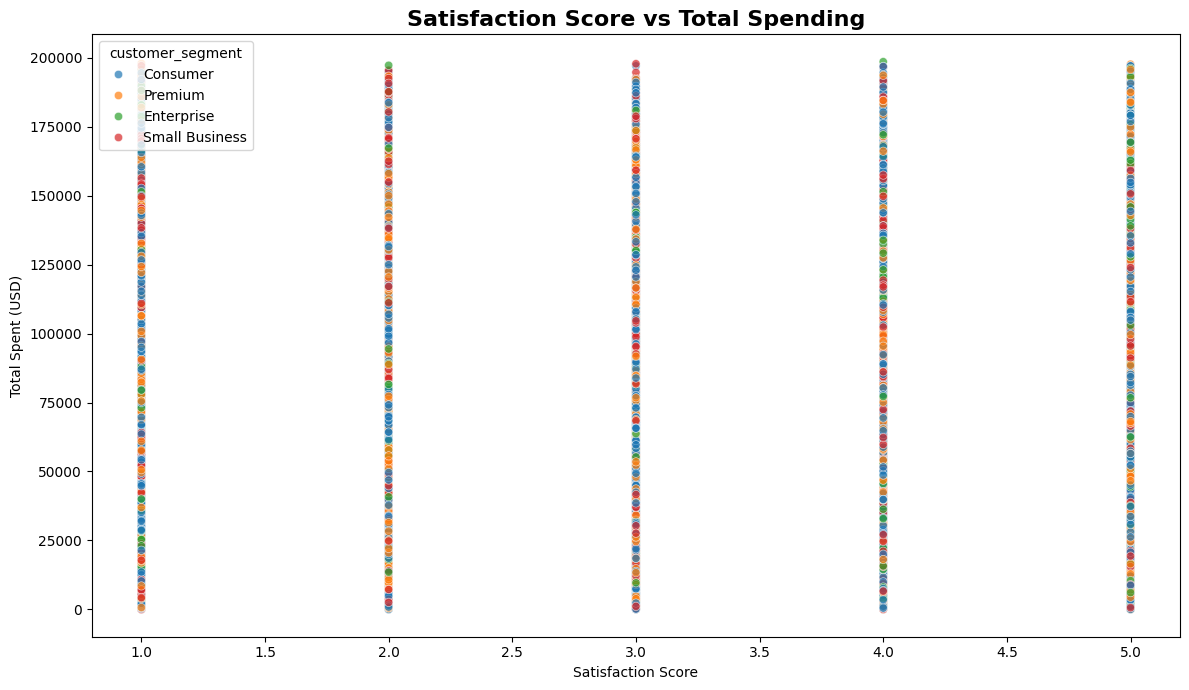

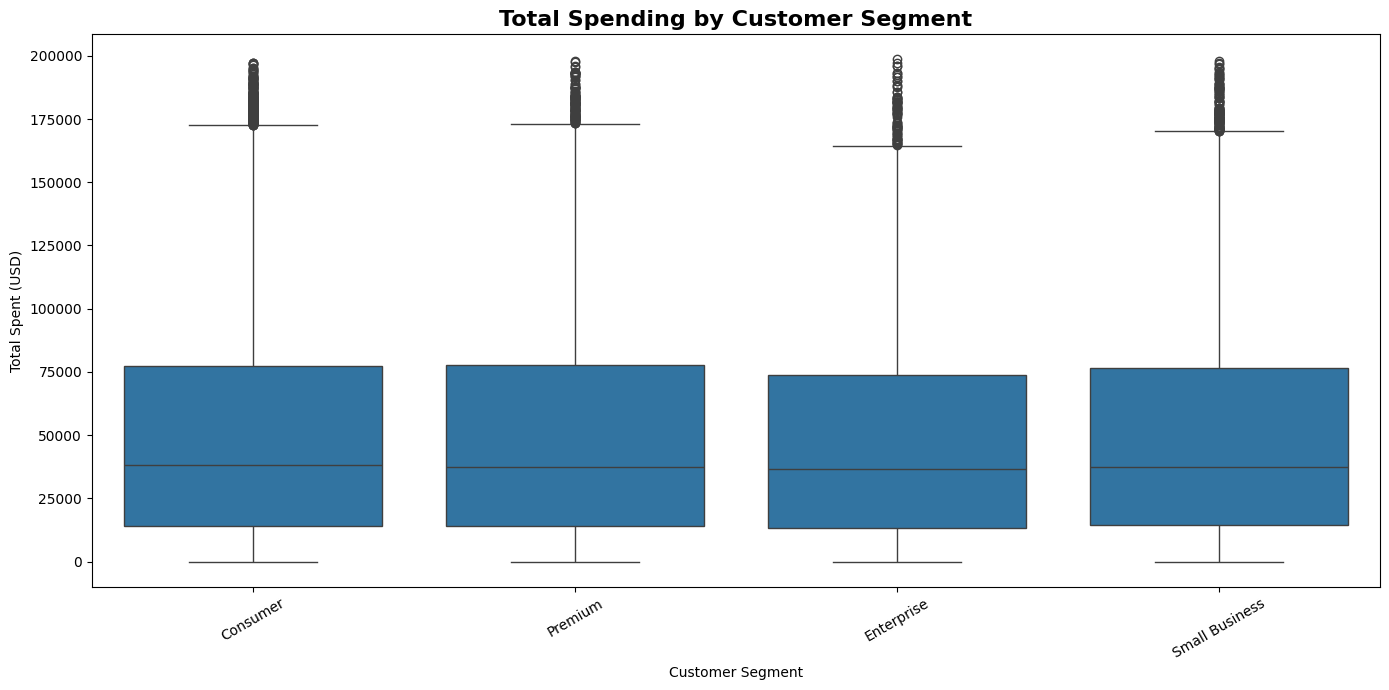

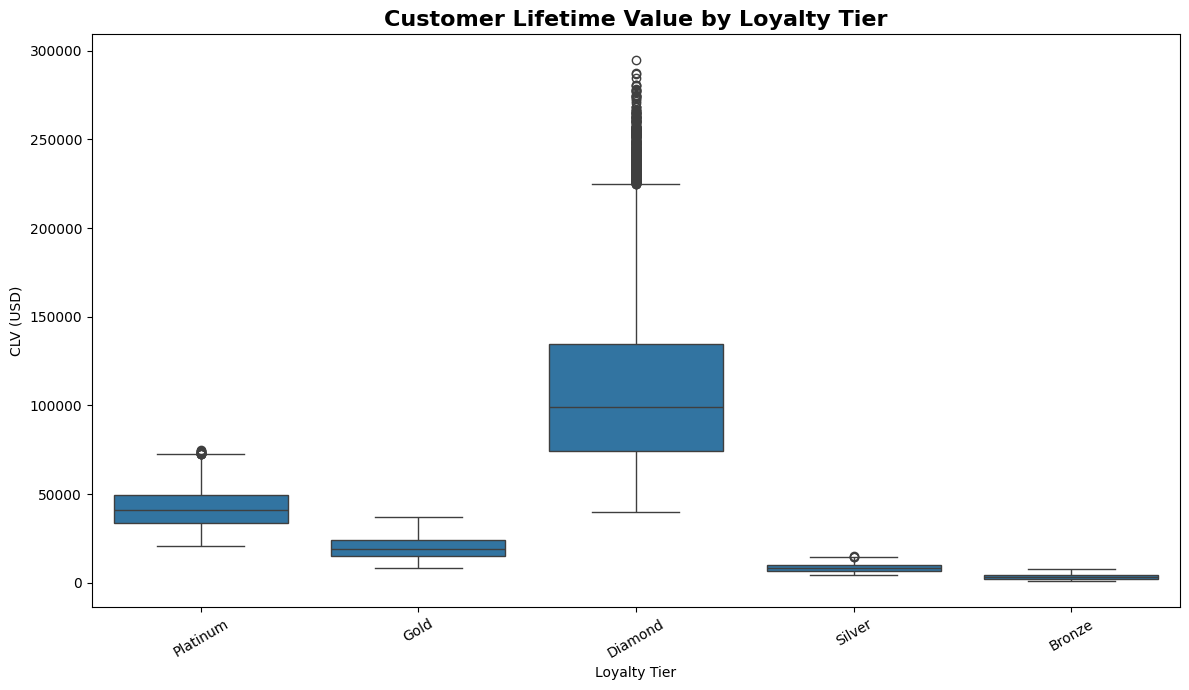

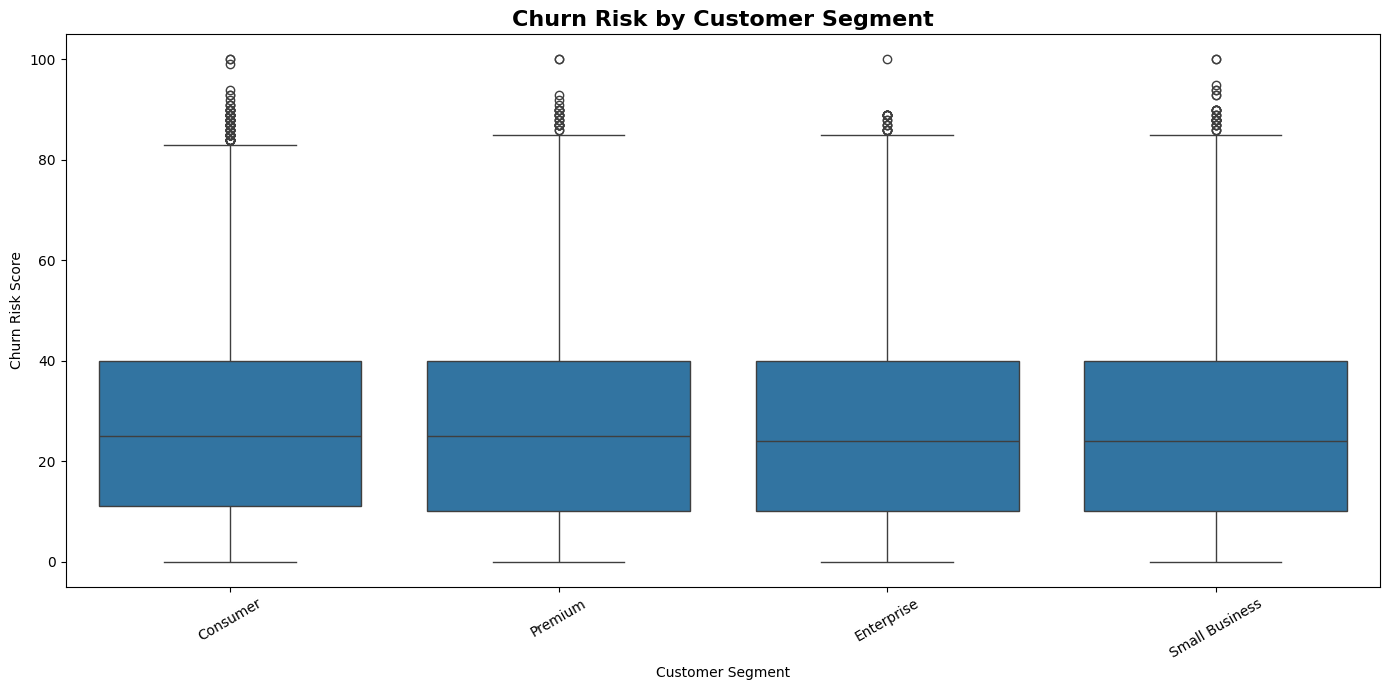

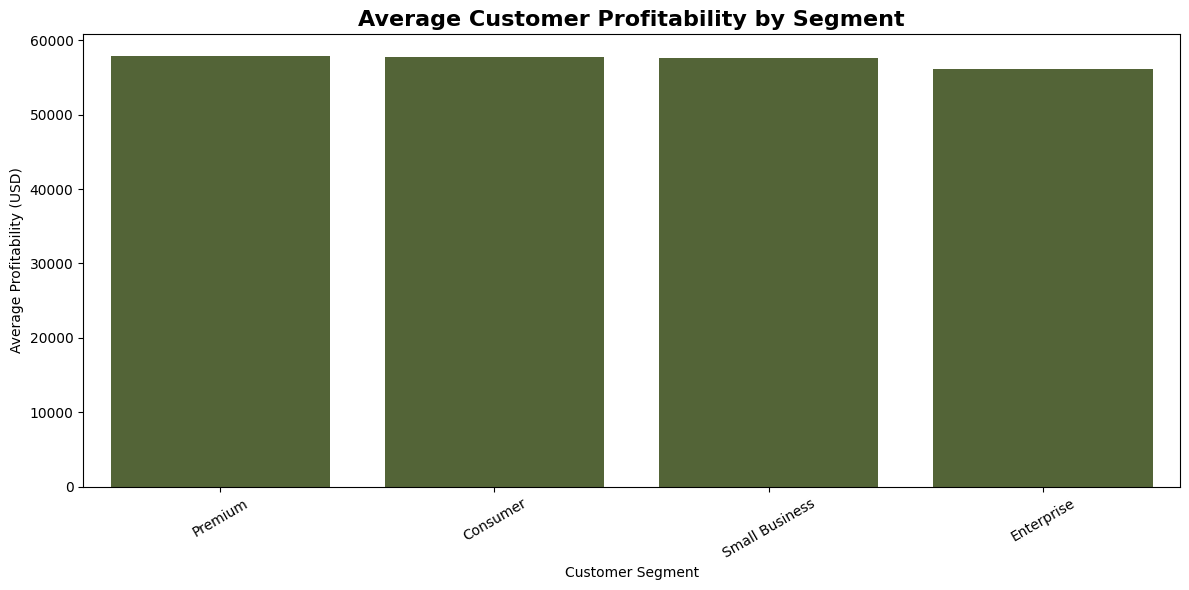

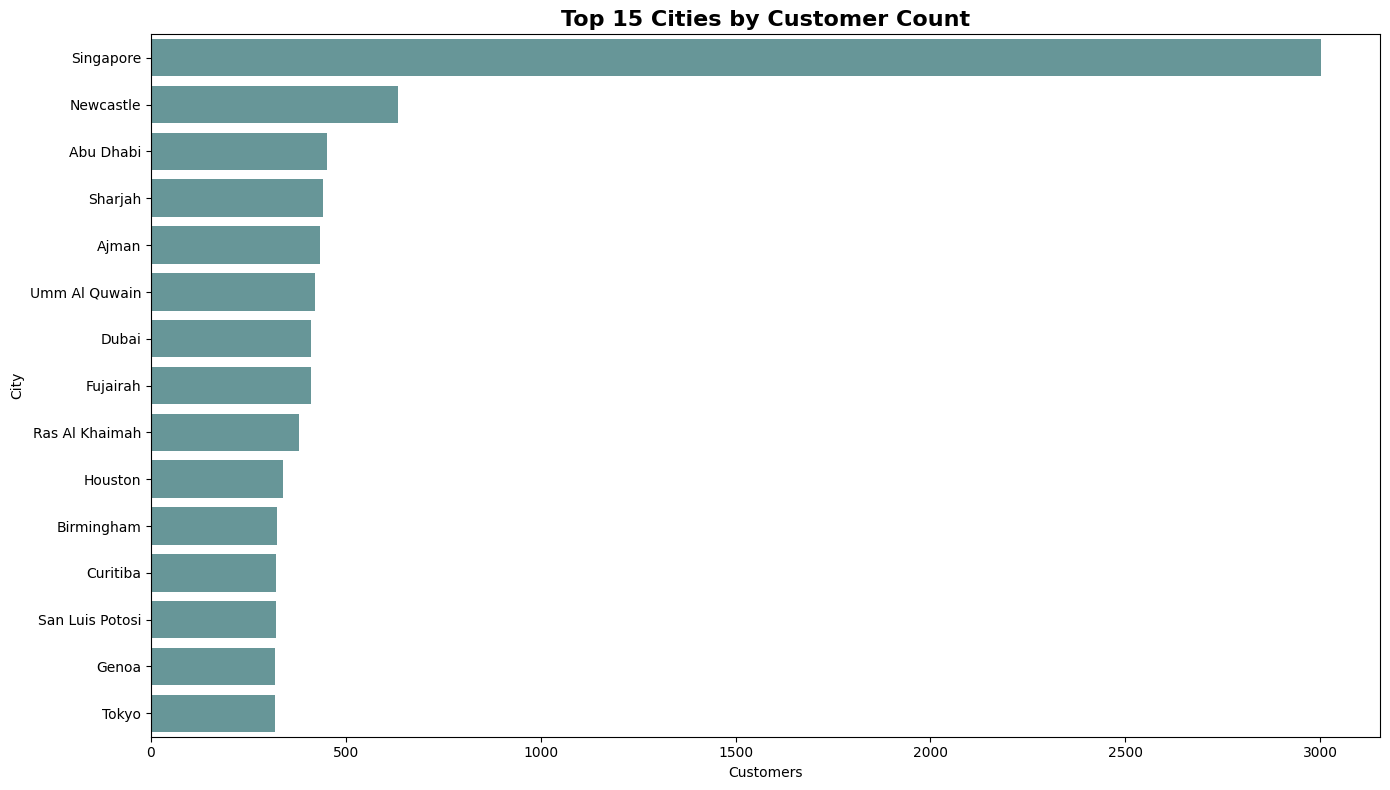


CUSTOMER ANALYTICS VISUALIZATION COMPLETED
Total Rows: 50000
Total Columns: 53
Total Customer Spending: 2513327307.8
Average Customer Lifetime Value: 57722.07
Average Customer Profitability: 57619.62
Average Churn Risk Score: 26.84

All available visualizations have been generated.


In [13]:
# ------------------------------------------------------------
# 2. BASIC DATA CLEANING
# ------------------------------------------------------------

# Remove duplicate records
df = df.drop_duplicates().copy()

# Convert numeric columns where possible
numeric_columns = [
    "age",
    "tenure_months",
    "total_purchases",
    "avg_order_value_usd",
    "total_spent_usd",
    "purchase_frequency",
    "days_since_last_purchase",
    "return_count",
    "complaint_count",
    "satisfaction_score",
    "email_open_rate",
    "click_through_rate",
    "conversion_rate",
    "social_media_presence",
    "customer_lifetime_value_usd",
    "customer_acquisition_cost_usd",
    "customer_profitability_usd",
    "recency_score",
    "frequency_score",
    "monetary_score",
    "rfm_score",
    "churn_risk_score",
    "customer_health_score",
    "dataset_year"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


# ------------------------------------------------------------
# 3. DATASET INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    print(missing)
else:
    print("No missing values found.")


print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)

print(df.dtypes)


# ------------------------------------------------------------
# 4. NUMERIC AND CATEGORICAL COLUMNS
# ------------------------------------------------------------

available_numeric = [
    col for col in numeric_columns
    if col in df.columns
]

categorical_columns = [
    col for col in df.columns
    if col not in available_numeric
]

print("\nNumeric Columns:")
print(available_numeric)

print("\nCategorical Columns:")
print(categorical_columns)


# ============================================================
# VISUALIZATION 1
# AGE DISTRIBUTION
# ============================================================

if "age" in df.columns:

    plt.figure(figsize=(12, 6))

    sns.histplot(
        df["age"].dropna(),
        bins=20,
        kde=True,
        color="royalblue"
    )

    plt.title(
        "Customer Age Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Age")
    plt.ylabel("Number of Customers")
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 2
# AGE GROUP
# ============================================================

if "age_group" in df.columns:

    plt.figure(figsize=(10, 6))

    order = df["age_group"].value_counts().index

    sns.countplot(
        data=df,
        x="age_group",
        order=order,
        color="darkorange"
    )

    plt.title(
        "Customers by Age Group",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Age Group")
    plt.ylabel("Customer Count")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 3
# GENDER DISTRIBUTION
# ============================================================

if "gender" in df.columns:

    gender_counts = df["gender"].value_counts()

    plt.figure(figsize=(8, 8))

    plt.pie(
        gender_counts,
        labels=gender_counts.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=[
            "cornflowerblue",
            "lightcoral",
            "mediumseagreen",
            "gold"
        ][:len(gender_counts)]
    )

    plt.title(
        "Customer Gender Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 4
# CUSTOMER SEGMENT
# ============================================================

if "customer_segment" in df.columns:

    plt.figure(figsize=(12, 6))

    segment_counts = df["customer_segment"].value_counts()

    sns.barplot(
        x=segment_counts.index,
        y=segment_counts.values,
        color="mediumpurple"
    )

    plt.title(
        "Customer Segment Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Customer Segment")
    plt.ylabel("Number of Customers")
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 5
# SEGMENT CATEGORY
# ============================================================

if "segment_category" in df.columns:

    plt.figure(figsize=(12, 6))

    counts = df["segment_category"].value_counts()

    sns.barplot(
        x=counts.index,
        y=counts.values,
        color="teal"
    )

    plt.title(
        "Segment Category Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Segment Category")
    plt.ylabel("Customers")
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 6
# INCOME BRACKET
# ============================================================

if "income_bracket" in df.columns:

    plt.figure(figsize=(12, 6))

    counts = df["income_bracket"].value_counts()

    sns.barplot(
        x=counts.index,
        y=counts.values,
        color="seagreen"
    )

    plt.title(
        "Customer Income Bracket",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Income Bracket")
    plt.ylabel("Customers")
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 7
# EDUCATION LEVEL
# ============================================================

if "education_level" in df.columns:

    plt.figure(figsize=(12, 6))

    counts = df["education_level"].value_counts()

    sns.barplot(
        x=counts.index,
        y=counts.values,
        color="crimson"
    )

    plt.title(
        "Education Level Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Education Level")
    plt.ylabel("Customers")
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 8
# EMPLOYMENT TYPE
# ============================================================

if "employment_type" in df.columns:

    plt.figure(figsize=(12, 6))

    counts = df["employment_type"].value_counts()

    sns.barplot(
        x=counts.index,
        y=counts.values,
        color="steelblue"
    )

    plt.title(
        "Employment Type Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Employment Type")
    plt.ylabel("Customers")
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 9
# COUNTRY DISTRIBUTION
# ============================================================

if "country" in df.columns:

    plt.figure(figsize=(14, 7))

    counts = df["country"].value_counts().head(15)

    sns.barplot(
        x=counts.values,
        y=counts.index,
        color="darkcyan"
    )

    plt.title(
        "Top 15 Countries by Customer Count",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Customers")
    plt.ylabel("Country")

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 10
# SHOPPING CHANNEL
# ============================================================

if "shopping_channel" in df.columns:

    plt.figure(figsize=(10, 6))

    counts = df["shopping_channel"].value_counts()

    sns.barplot(
        x=counts.index,
        y=counts.values,
        color="orange"
    )

    plt.title(
        "Shopping Channel Usage",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Shopping Channel")
    plt.ylabel("Customers")
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 11
# DEVICE USED
# ============================================================

if "device_used" in df.columns:

    plt.figure(figsize=(10, 6))

    counts = df["device_used"].value_counts()

    sns.barplot(
        x=counts.index,
        y=counts.values,
        color="slateblue"
    )

    plt.title(
        "Device Usage",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Device")
    plt.ylabel("Customers")

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 12
# PAYMENT METHOD
# ============================================================

if "payment_method" in df.columns:

    plt.figure(figsize=(10, 6))

    counts = df["payment_method"].value_counts()

    sns.barplot(
        x=counts.index,
        y=counts.values,
        color="mediumvioletred"
    )

    plt.title(
        "Payment Method Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Payment Method")
    plt.ylabel("Customers")
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 13
# TOTAL PURCHASES
# ============================================================

if "total_purchases" in df.columns:

    plt.figure(figsize=(12, 6))

    sns.histplot(
        df["total_purchases"].dropna(),
        bins=30,
        kde=True,
        color="forestgreen"
    )

    plt.title(
        "Distribution of Total Purchases",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Total Purchases")
    plt.ylabel("Customers")

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 14
# TOTAL SPENT
# ============================================================

if "total_spent_usd" in df.columns:

    plt.figure(figsize=(12, 6))

    sns.histplot(
        df["total_spent_usd"].dropna(),
        bins=30,
        kde=True,
        color="darkorange"
    )

    plt.title(
        "Customer Total Spending Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Total Spent (USD)")
    plt.ylabel("Customers")

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 15
# AVERAGE ORDER VALUE
# ============================================================

if "avg_order_value_usd" in df.columns:

    plt.figure(figsize=(12, 6))

    sns.histplot(
        df["avg_order_value_usd"].dropna(),
        bins=30,
        kde=True,
        color="mediumseagreen"
    )

    plt.title(
        "Average Order Value Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Average Order Value (USD)")
    plt.ylabel("Customers")

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 16
# PURCHASE FREQUENCY
# ============================================================

if "purchase_frequency" in df.columns:

    plt.figure(figsize=(12, 6))

    sns.histplot(
        df["purchase_frequency"].dropna(),
        bins=25,
        kde=True,
        color="darkviolet"
    )

    plt.title(
        "Purchase Frequency Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Purchase Frequency")
    plt.ylabel("Customers")

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 17
# DAYS SINCE LAST PURCHASE
# ============================================================

if "days_since_last_purchase" in df.columns:

    plt.figure(figsize=(12, 6))

    sns.histplot(
        df["days_since_last_purchase"].dropna(),
        bins=30,
        kde=True,
        color="firebrick"
    )

    plt.title(
        "Days Since Last Purchase",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Days Since Last Purchase")
    plt.ylabel("Customers")

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 18
# RETURN COUNT
# ============================================================

if "return_count" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        df["return_count"].dropna(),
        bins=20,
        color="goldenrod"
    )

    plt.title(
        "Customer Return Count",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Return Count")
    plt.ylabel("Customers")

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 19
# COMPLAINT COUNT
# ============================================================

if "complaint_count" in df.columns:

    plt.figure(figsize=(10, 6))

    sns.histplot(
        df["complaint_count"].dropna(),
        bins=20,
        color="indianred"
    )

    plt.title(
        "Customer Complaint Count",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Complaint Count")
    plt.ylabel("Customers")

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 20
# SATISFACTION SCORE
# ============================================================

if "satisfaction_score" in df.columns:

    plt.figure(figsize=(12, 6))

    sns.histplot(
        df["satisfaction_score"].dropna(),
        bins=20,
        kde=True,
        color="royalblue"
    )

    plt.title(
        "Customer Satisfaction Score",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Satisfaction Score")
    plt.ylabel("Customers")

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 21
# SATISFACTION LEVEL
# ============================================================

if "satisfaction_level" in df.columns:

    plt.figure(figsize=(10, 6))

    counts = df["satisfaction_level"].value_counts()

    sns.barplot(
        x=counts.index,
        y=counts.values,
        color="mediumseagreen"
    )

    plt.title(
        "Satisfaction Level",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Satisfaction Level")
    plt.ylabel("Customers")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 22
# LOYALTY TIER
# ============================================================

if "loyalty_tier" in df.columns:

    plt.figure(figsize=(10, 6))

    counts = df["loyalty_tier"].value_counts()

    sns.barplot(
        x=counts.index,
        y=counts.values,
        color="gold"
    )

    plt.title(
        "Customer Loyalty Tier",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Loyalty Tier")
    plt.ylabel("Customers")

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 23
# EMAIL OPEN RATE
# ============================================================

if "email_open_rate" in df.columns:

    plt.figure(figsize=(12, 6))

    sns.histplot(
        df["email_open_rate"].dropna(),
        bins=25,
        kde=True,
        color="dodgerblue"
    )

    plt.title(
        "Email Open Rate Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Email Open Rate")
    plt.ylabel("Customers")

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 24
# CLICK THROUGH RATE
# ============================================================

if "click_through_rate" in df.columns:

    plt.figure(figsize=(12, 6))

    sns.histplot(
        df["click_through_rate"].dropna(),
        bins=25,
        kde=True,
        color="mediumorchid"
    )

    plt.title(
        "Click Through Rate Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Click Through Rate")
    plt.ylabel("Customers")

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 25
# CONVERSION RATE
# ============================================================

if "conversion_rate" in df.columns:

    plt.figure(figsize=(12, 6))

    sns.histplot(
        df["conversion_rate"].dropna(),
        bins=25,
        kde=True,
        color="seagreen"
    )

    plt.title(
        "Conversion Rate Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Conversion Rate")
    plt.ylabel("Customers")

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 26
# CUSTOMER LIFETIME VALUE
# ============================================================

if "customer_lifetime_value_usd" in df.columns:

    plt.figure(figsize=(12, 6))

    sns.histplot(
        df["customer_lifetime_value_usd"].dropna(),
        bins=30,
        kde=True,
        color="purple"
    )

    plt.title(
        "Customer Lifetime Value Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Customer Lifetime Value (USD)")
    plt.ylabel("Customers")

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 27
# CUSTOMER ACQUISITION COST
# ============================================================

if "customer_acquisition_cost_usd" in df.columns:

    plt.figure(figsize=(12, 6))

    sns.histplot(
        df["customer_acquisition_cost_usd"].dropna(),
        bins=30,
        kde=True,
        color="brown"
    )

    plt.title(
        "Customer Acquisition Cost Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Customer Acquisition Cost (USD)")
    plt.ylabel("Customers")

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 28
# CUSTOMER PROFITABILITY
# ============================================================

if "customer_profitability_usd" in df.columns:

    plt.figure(figsize=(12, 6))

    sns.histplot(
        df["customer_profitability_usd"].dropna(),
        bins=30,
        kde=True,
        color="darkgreen"
    )

    plt.title(
        "Customer Profitability Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Customer Profitability (USD)")
    plt.ylabel("Customers")

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 29
# RFM SCORE
# ============================================================

if "rfm_score" in df.columns:

    plt.figure(figsize=(12, 6))

    sns.histplot(
        df["rfm_score"].dropna(),
        bins=30,
        kde=True,
        color="darkcyan"
    )

    plt.title(
        "RFM Score Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("RFM Score")
    plt.ylabel("Customers")

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 30
# RFM CATEGORY
# ============================================================

if "rfm_category" in df.columns:

    plt.figure(figsize=(12, 6))

    counts = df["rfm_category"].value_counts()

    sns.barplot(
        x=counts.index,
        y=counts.values,
        color="tomato"
    )

    plt.title(
        "RFM Category Distribution",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("RFM Category")
    plt.ylabel("Customers")
    plt.xticks(rotation=40)

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 31
# CHURN RISK SCORE
# ============================================================

if "churn_risk_score" in df.columns:

    plt.figure(figsize=(12, 6))

    sns.histplot(
        df["churn_risk_score"].dropna(),
        bins=30,
        kde=True,
        color="red"
    )

    plt.title(
        "Customer Churn Risk Score",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Churn Risk Score")
    plt.ylabel("Customers")

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 32
# CHURN RISK CATEGORY
# ============================================================

if "churn_risk_category" in df.columns:

    plt.figure(figsize=(10, 6))

    counts = df["churn_risk_category"].value_counts()

    sns.barplot(
        x=counts.index,
        y=counts.values,
        color="orangered"
    )

    plt.title(
        "Churn Risk Category",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Churn Risk Category")
    plt.ylabel("Customers")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 33
# CUSTOMER HEALTH SCORE
# ============================================================

if "customer_health_score" in df.columns:

    plt.figure(figsize=(12, 6))

    sns.histplot(
        df["customer_health_score"].dropna(),
        bins=30,
        kde=True,
        color="limegreen"
    )

    plt.title(
        "Customer Health Score",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Customer Health Score")
    plt.ylabel("Customers")

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 34
# HEALTH STATUS
# ============================================================

if "health_status" in df.columns:

    plt.figure(figsize=(10, 6))

    counts = df["health_status"].value_counts()

    sns.barplot(
        x=counts.index,
        y=counts.values,
        color="mediumaquamarine"
    )

    plt.title(
        "Customer Health Status",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Health Status")
    plt.ylabel("Customers")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 35
# ACTIVITY STATUS
# ============================================================

if "activity_status" in df.columns:

    plt.figure(figsize=(10, 6))

    counts = df["activity_status"].value_counts()

    sns.barplot(
        x=counts.index,
        y=counts.values,
        color="royalblue"
    )

    plt.title(
        "Customer Activity Status",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Activity Status")
    plt.ylabel("Customers")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 36
# PROFITABILITY CATEGORY
# ============================================================

if "profitability_category" in df.columns:

    plt.figure(figsize=(10, 6))

    counts = df["profitability_category"].value_counts()

    sns.barplot(
        x=counts.index,
        y=counts.values,
        color="darkseagreen"
    )

    plt.title(
        "Customer Profitability Category",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Profitability Category")
    plt.ylabel("Customers")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 37
# ENGAGEMENT LEVEL
# ============================================================

if "engagement_level" in df.columns:

    plt.figure(figsize=(10, 6))

    counts = df["engagement_level"].value_counts()

    sns.barplot(
        x=counts.index,
        y=counts.values,
        color="mediumblue"
    )

    plt.title(
        "Customer Engagement Level",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Engagement Level")
    plt.ylabel("Customers")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 38
# BEHAVIOR SEGMENT
# ============================================================

if "behavior_segment" in df.columns:

    plt.figure(figsize=(12, 6))

    counts = df["behavior_segment"].value_counts()

    sns.barplot(
        x=counts.index,
        y=counts.values,
        color="orchid"
    )

    plt.title(
        "Customer Behavior Segment",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Behavior Segment")
    plt.ylabel("Customers")

    plt.xticks(rotation=40)

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 39
# DEVICE PREFERENCE
# ============================================================

if "device_preference" in df.columns:

    plt.figure(figsize=(10, 6))

    counts = df["device_preference"].value_counts()

    sns.barplot(
        x=counts.index,
        y=counts.values,
        color="steelblue"
    )

    plt.title(
        "Customer Device Preference",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Device Preference")
    plt.ylabel("Customers")

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 40
# CLV CATEGORY
# ============================================================

if "clv_category" in df.columns:

    plt.figure(figsize=(10, 6))

    counts = df["clv_category"].value_counts()

    sns.barplot(
        x=counts.index,
        y=counts.values,
        color="goldenrod"
    )

    plt.title(
        "Customer Lifetime Value Category",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("CLV Category")
    plt.ylabel("Customers")

    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 41
# CORRELATION HEATMAP
# ============================================================

if len(available_numeric) >= 2:

    correlation = df[available_numeric].corr()

    plt.figure(figsize=(18, 14))

    sns.heatmap(
        correlation,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5
    )

    plt.title(
        "Customer Numerical Feature Correlation",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 42
# CUSTOMER SPENDING VS CLV
# ============================================================

if (
    "total_spent_usd" in df.columns
    and "customer_lifetime_value_usd" in df.columns
):

    plt.figure(figsize=(12, 7))

    sns.scatterplot(
        data=df,
        x="total_spent_usd",
        y="customer_lifetime_value_usd",
        hue="customer_segment"
        if "customer_segment" in df.columns
        else None,
        alpha=0.7
    )

    plt.title(
        "Total Spending vs Customer Lifetime Value",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Total Spent (USD)")
    plt.ylabel("Customer Lifetime Value (USD)")

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 43
# PURCHASES VS SPENDING
# ============================================================

if (
    "total_purchases" in df.columns
    and "total_spent_usd" in df.columns
):

    plt.figure(figsize=(12, 7))

    sns.scatterplot(
        data=df,
        x="total_purchases",
        y="total_spent_usd",
        hue="loyalty_tier"
        if "loyalty_tier" in df.columns
        else None,
        alpha=0.7
    )

    plt.title(
        "Total Purchases vs Total Spending",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Total Purchases")
    plt.ylabel("Total Spent (USD)")

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 44
# CHURN RISK VS CUSTOMER HEALTH
# ============================================================

if (
    "churn_risk_score" in df.columns
    and "customer_health_score" in df.columns
):

    plt.figure(figsize=(12, 7))

    sns.scatterplot(
        data=df,
        x="customer_health_score",
        y="churn_risk_score",
        hue="churn_risk_category"
        if "churn_risk_category" in df.columns
        else None,
        alpha=0.7
    )

    plt.title(
        "Customer Health Score vs Churn Risk",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Customer Health Score")
    plt.ylabel("Churn Risk Score")

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 45
# SATISFACTION VS SPENDING
# ============================================================

if (
    "satisfaction_score" in df.columns
    and "total_spent_usd" in df.columns
):

    plt.figure(figsize=(12, 7))

    sns.scatterplot(
        data=df,
        x="satisfaction_score",
        y="total_spent_usd",
        hue="customer_segment"
        if "customer_segment" in df.columns
        else None,
        alpha=0.7
    )

    plt.title(
        "Satisfaction Score vs Total Spending",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Satisfaction Score")
    plt.ylabel("Total Spent (USD)")

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 46
# BOXPLOT - SPENDING BY SEGMENT
# ============================================================

if (
    "customer_segment" in df.columns
    and "total_spent_usd" in df.columns
):

    plt.figure(figsize=(14, 7))

    sns.boxplot(
        data=df,
        x="customer_segment",
        y="total_spent_usd"
    )

    plt.title(
        "Total Spending by Customer Segment",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Customer Segment")
    plt.ylabel("Total Spent (USD)")
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 47
# BOXPLOT - CLV BY LOYALTY
# ============================================================

if (
    "loyalty_tier" in df.columns
    and "customer_lifetime_value_usd" in df.columns
):

    plt.figure(figsize=(12, 7))

    sns.boxplot(
        data=df,
        x="loyalty_tier",
        y="customer_lifetime_value_usd"
    )

    plt.title(
        "Customer Lifetime Value by Loyalty Tier",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Loyalty Tier")
    plt.ylabel("CLV (USD)")
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 48
# BOXPLOT - CHURN RISK BY SEGMENT
# ============================================================

if (
    "customer_segment" in df.columns
    and "churn_risk_score" in df.columns
):

    plt.figure(figsize=(14, 7))

    sns.boxplot(
        data=df,
        x="customer_segment",
        y="churn_risk_score"
    )

    plt.title(
        "Churn Risk by Customer Segment",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Customer Segment")
    plt.ylabel("Churn Risk Score")
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 49
# DEPARTMENT-LIKE BUSINESS SUMMARY
# ============================================================

if (
    "customer_segment" in df.columns
    and "customer_profitability_usd" in df.columns
):

    summary = (
        df.groupby("customer_segment")[
            "customer_profitability_usd"
        ]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(12, 6))

    sns.barplot(
        x=summary.index,
        y=summary.values,
        color="darkolivegreen"
    )

    plt.title(
        "Average Customer Profitability by Segment",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Customer Segment")
    plt.ylabel("Average Profitability (USD)")
    plt.xticks(rotation=30)

    plt.tight_layout()
    plt.show()


# ============================================================
# VISUALIZATION 50
# TOP CITIES
# ============================================================

if "city" in df.columns:

    plt.figure(figsize=(14, 8))

    counts = df["city"].value_counts().head(15)

    sns.barplot(
        x=counts.values,
        y=counts.index,
        color="cadetblue"
    )

    plt.title(
        "Top 15 Cities by Customer Count",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel("Customers")
    plt.ylabel("City")

    plt.tight_layout()
    plt.show()


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("CUSTOMER ANALYTICS VISUALIZATION COMPLETED")
print("=" * 70)

print("Total Rows:", len(df))
print("Total Columns:", len(df.columns))

if "total_spent_usd" in df.columns:
    print(
        "Total Customer Spending:",
        round(df["total_spent_usd"].sum(), 2)
    )

if "customer_lifetime_value_usd" in df.columns:
    print(
        "Average Customer Lifetime Value:",
        round(df["customer_lifetime_value_usd"].mean(), 2)
    )

if "customer_profitability_usd" in df.columns:
    print(
        "Average Customer Profitability:",
        round(df["customer_profitability_usd"].mean(), 2)
    )

if "churn_risk_score" in df.columns:
    print(
        "Average Churn Risk Score:",
        round(df["churn_risk_score"].mean(), 2)
    )

print("\nAll available visualizations have been generated.")

## Feature Engineering


Number of columns: 53

Duplicate rows: 0
Shape after duplicate removal: (50000, 53)

Target column: churn_risk_category

Missing target values: 0

Target distribution:
churn_risk_category
Very Low     20604
Low          17203
Medium        9491
High          2395
Very High      307
Name: count, dtype: int64

Removed leakage columns:
['churn_risk_score', 'customer_health_score', 'health_status', 'customer_value_category', 'activity_status', 'rfm_category', 'profitability_category', 'engagement_level', 'behavior_segment', 'clv_category']

Feature shape:
(50000, 41)

Target shape:
(50000,)

Numeric columns:
['age', 'tenure_months', 'total_purchases', 'avg_order_value_usd', 'total_spent_usd', 'purchase_frequency', 'days_since_last_purchase', 'return_count', 'complaint_count', 'satisfaction_score', 'email_open_rate', 'click_through_rate', 'conversion_rate', 'social_media_presence', 'customer_lifetime_value_usd', 'customer_acquisition_cost_usd', 'customer_profitability_usd', 'recency_score'

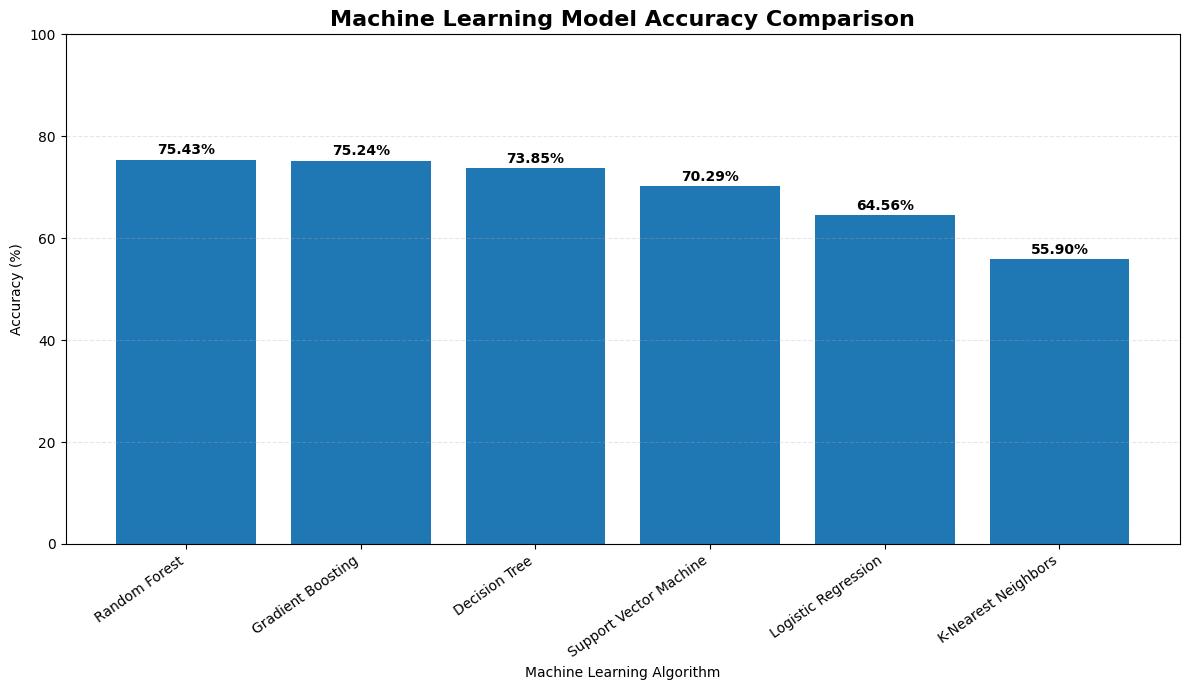



CLASSIFICATION REPORT - Random Forest
              precision    recall  f1-score   support

        High       0.64      0.62      0.63       479
         Low       0.67      0.76      0.71      3441
      Medium       0.69      0.54      0.61      1898
   Very High       0.58      0.11      0.19        61
    Very Low       0.87      0.87      0.87      4121

    accuracy                           0.75     10000
   macro avg       0.69      0.58      0.60     10000
weighted avg       0.75      0.75      0.75     10000



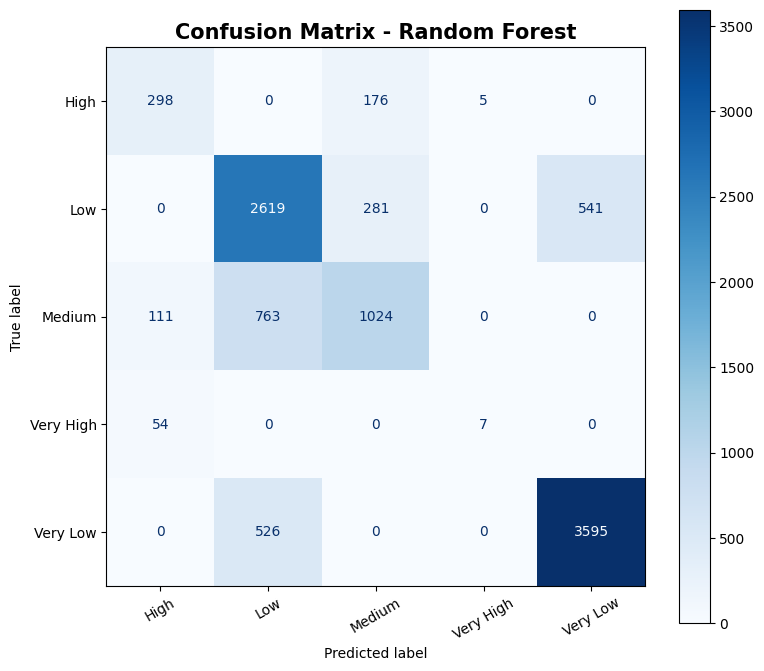



ROC CURVE / AUC


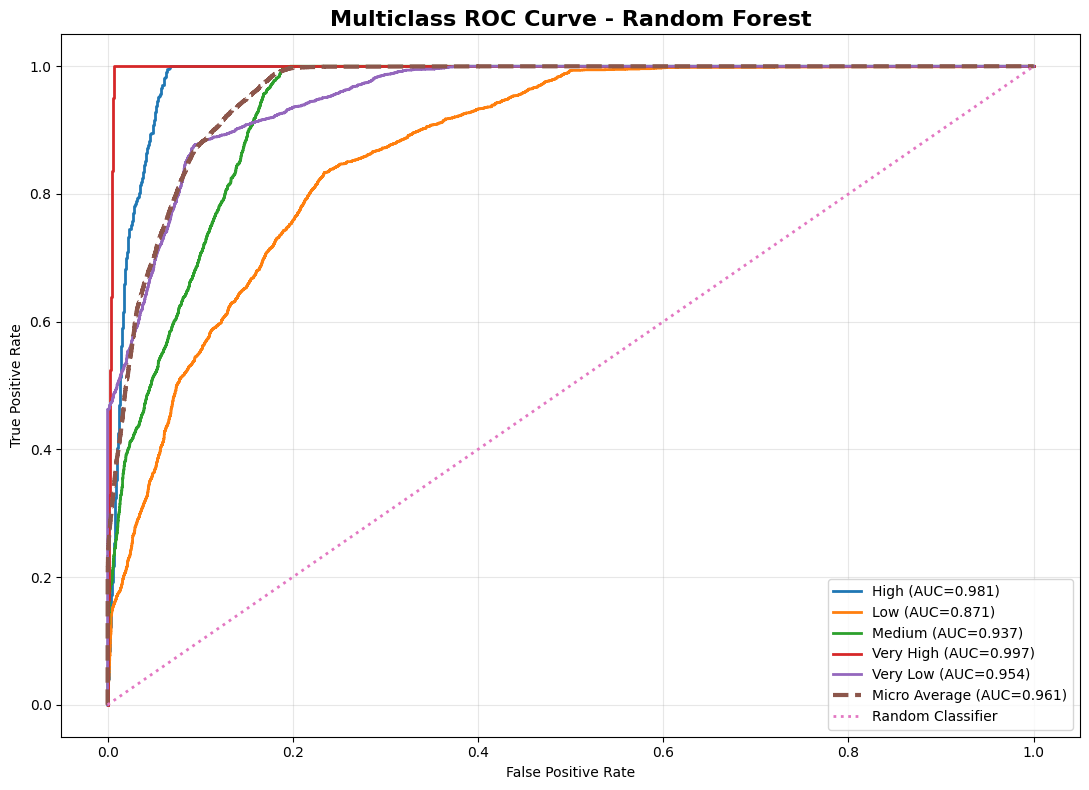


Class-wise AUC:
High: 0.9810 (98.10%)
Low: 0.8708 (87.08%)
Medium: 0.9369 (93.69%)
Very High: 0.9968 (99.68%)
Very Low: 0.9543 (95.43%)

Micro Average AUC: 0.9607
Micro Average AUC Percentage: 96.07%


FINAL MACHINE LEARNING SUMMARY
Dataset Rows       : 50000
Features Used      : 41
Training Samples   : 40000
Testing Samples    : 10000
Target             : churn_risk_category
Number of Classes  : 5
Best Model         : Random Forest
Best Accuracy      : 75.43%

ML analysis completed successfully.


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)




# ============================================================
# 2. CLEAN COLUMN NAMES
# ============================================================

df.columns = df.columns.str.strip()

print("\nNumber of columns:", len(df.columns))


# ============================================================
# 3. REMOVE DUPLICATES
# ============================================================

duplicate_count = df.duplicated().sum()

print("\nDuplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)

print("Shape after duplicate removal:", df.shape)


# ============================================================
# 4. TARGET COLUMN
# ============================================================

TARGET = "churn_risk_category"

if TARGET not in df.columns:

    raise ValueError(
        f"\nTarget column '{TARGET}' not found.\n\n"
        f"Available columns:\n{df.columns.tolist()}"
    )

print("\nTarget column:", TARGET)


# ============================================================
# 5. REMOVE MISSING TARGET VALUES
# ============================================================

missing_target = df[TARGET].isna().sum()

print(
    "\nMissing target values:",
    missing_target
)

if missing_target > 0:

    df = df.dropna(
        subset=[TARGET]
    ).reset_index(drop=True)


# ============================================================
# 6. TARGET DISTRIBUTION
# ============================================================

print("\nTarget distribution:")

print(
    df[TARGET].value_counts()
)

if df[TARGET].nunique() < 2:

    raise ValueError(
        "The target column must contain at least 2 classes."
    )


# ============================================================
# 7. REMOVE CUSTOMER ID
# ============================================================

if "customer_id" in df.columns:

    df = df.drop(
        columns=["customer_id"]
    )


# ============================================================
# 8. REMOVE POSSIBLE DATA LEAKAGE
# ============================================================

LEAKAGE_COLUMNS = [
    "churn_risk_score",
    "customer_health_score",
    "health_status",
    "customer_value_category",
    "activity_status",
    "rfm_category",
    "profitability_category",
    "engagement_level",
    "behavior_segment",
    "clv_category"
]

removed_columns = []

for column in LEAKAGE_COLUMNS:

    if (
        column in df.columns
        and column != TARGET
    ):

        df = df.drop(
            columns=[column]
        )

        removed_columns.append(column)


print("\nRemoved leakage columns:")

print(
    removed_columns
)


# ============================================================
# 9. SEPARATE FEATURES AND TARGET
# ============================================================

X = df.drop(
    columns=[TARGET]
).copy()

y = df[TARGET].copy()


print("\nFeature shape:")
print(X.shape)

print("\nTarget shape:")
print(y.shape)


# ============================================================
# 10. REPLACE INFINITE VALUES
# ============================================================

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)


# ============================================================
# 11. IDENTIFY CATEGORICAL COLUMNS
# ============================================================

categorical_columns = X.select_dtypes(
    include=[
        "object",
        "category",
        "bool"
    ]
).columns.tolist()


numeric_columns = X.select_dtypes(
    include=[
        "number"
    ]
).columns.tolist()


print("\nNumeric columns:")

print(
    numeric_columns
)


print("\nCategorical columns:")

print(
    categorical_columns
)


# ============================================================
# 12. MISSING VALUE REPORT
# ============================================================

print("\n")
print("=" * 70)
print("MISSING VALUE REPORT")
print("=" * 70)

missing_values = X.isna().sum()

missing_values = missing_values[
    missing_values > 0
].sort_values(
    ascending=False
)

if len(missing_values) > 0:

    print(
        missing_values
    )

else:

    print(
        "No missing values found."
    )


# ============================================================
# 13. HANDLE CATEGORICAL MISSING VALUES
# ============================================================

for column in categorical_columns:

    X[column] = X[column].fillna(
        "Missing"
    )

    X[column] = X[column].astype(str)


# ============================================================
# 14. LABEL ENCODING
# ============================================================

label_encoders = {}

print("\n")
print("=" * 70)
print("LABEL ENCODING")
print("=" * 70)

for column in categorical_columns:

    encoder = LabelEncoder()

    X[column] = encoder.fit_transform(
        X[column]
    )

    label_encoders[column] = encoder

    print(
        f"{column} -> "
        f"{len(encoder.classes_)} categories"
    )


# ============================================================
# 15. CONVERT FEATURES TO NUMERIC
# ============================================================

for column in X.columns:

    X[column] = pd.to_numeric(
        X[column],
        errors="coerce"
    )


# ============================================================
# 16. COUNT NaN BEFORE IMPUTATION
# ============================================================

print("\n")
print("=" * 70)
print("NaN VALUES BEFORE IMPUTATION")
print("=" * 70)

print(
    "Total NaN:",
    X.isna().sum().sum()
)


# ============================================================
# 17. IMPUTE NUMERIC MISSING VALUES
# ============================================================
#
# IMPORTANT:
# keep_empty_features=True prevents sklearn from dropping
# columns that contain only NaN values.
#

imputer = SimpleImputer(
    strategy="median",
    keep_empty_features=True
)


X_array = imputer.fit_transform(
    X
)


# ============================================================
# 18. VERIFY FEATURE COUNT
# ============================================================

print("\n")
print("=" * 70)
print("FEATURE COUNT CHECK")
print("=" * 70)

print(
    "Before imputation:",
    X.shape
)

print(
    "After imputation:",
    X_array.shape
)


# ============================================================
# 19. RECREATE DATAFRAME
# ============================================================

X = pd.DataFrame(
    X_array,
    columns=X.columns,
    index=X.index
)


# ============================================================
# 20. FINAL NaN CHECK
# ============================================================

remaining_nan = X.isna().sum().sum()

remaining_inf = np.isinf(
    X.to_numpy()
).sum()


print("\n")
print("=" * 70)
print("FINAL DATA CHECK")
print("=" * 70)

print(
    "Remaining NaN:",
    remaining_nan
)

print(
    "Remaining Infinite:",
    remaining_inf
)


if remaining_nan > 0:

    raise ValueError(
        "NaN values are still present after imputation."
    )


if remaining_inf > 0:

    raise ValueError(
        "Infinite values are still present."
    )


# ============================================================
# 21. ENCODE TARGET
# ============================================================

target_encoder = LabelEncoder()

y_encoded = target_encoder.fit_transform(
    y.astype(str)
)

class_names = target_encoder.classes_


print("\n")
print("=" * 70)
print("TARGET ENCODING")
print("=" * 70)

for number, class_name in enumerate(
    class_names
):

    print(
        f"{number} = {class_name}"
    )


# ============================================================
# 22. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y_encoded,

    test_size=0.20,

    random_state=42,

    stratify=y_encoded
)


print("\n")
print("=" * 70)
print("TRAIN TEST SPLIT")
print("=" * 70)

print(
    "X_train:",
    X_train.shape
)

print(
    "X_test:",
    X_test.shape
)

print(
    "y_train:",
    y_train.shape
)

print(
    "y_test:",
    y_test.shape
)


# ============================================================
# 23. STANDARD SCALER
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)


# ============================================================
# 24. FINAL NaN / INFINITE CHECK
# ============================================================

print("\n")
print("=" * 70)
print("SCALED DATA VALIDATION")
print("=" * 70)

print(
    "Training NaN:",
    np.isnan(X_train_scaled).sum()
)

print(
    "Testing NaN:",
    np.isnan(X_test_scaled).sum()
)

print(
    "Training Infinite:",
    np.isinf(X_train_scaled).sum()
)

print(
    "Testing Infinite:",
    np.isinf(X_test_scaled).sum()
)


# ============================================================
# 25. DEFINE ML MODELS
# ============================================================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=3000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=10,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ),

    "K-Nearest Neighbors":
        KNeighborsClassifier(
            n_neighbors=5
        ),

    "Support Vector Machine":
        SVC(
            probability=True,
            random_state=42
        )
}


# ============================================================
# 26. TRAIN MODELS
# ============================================================

results = []

trained_models = {}

predictions = {}

probabilities = {}


print("\n")
print("=" * 70)
print("MODEL TRAINING")
print("=" * 70)


for model_name, model in models.items():

    print(
        f"\nTraining: {model_name}"
    )

    try:

        # Train model
        model.fit(
            X_train_scaled,
            y_train
        )

        # Predict
        y_pred = model.predict(
            X_test_scaled
        )

        # Accuracy
        accuracy = accuracy_score(
            y_test,
            y_pred
        )

        accuracy_percentage = (
            accuracy * 100
        )

        print(
            f"Accuracy: "
            f"{accuracy_percentage:.2f}%"
        )

        # Save
        trained_models[
            model_name
        ] = model

        predictions[
            model_name
        ] = y_pred

        # Probability
        if hasattr(
            model,
            "predict_proba"
        ):

            probabilities[
                model_name
            ] = model.predict_proba(
                X_test_scaled
            )

        results.append({

            "Model": model_name,

            "Accuracy (%)":
                accuracy_percentage

        })

    except Exception as error:

        print(
            f"Error in {model_name}: "
            f"{error}"
        )


# ============================================================
# 27. RESULTS
# ============================================================

if len(results) == 0:

    raise ValueError(
        "No model was successfully trained."
    )


results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(
    drop=True
)


print("\n")
print("=" * 70)
print("MODEL ACCURACY RESULTS")
print("=" * 70)

print(
    results_df.to_string(
        index=False
    )
)


# ============================================================
# 28. BEST MODEL
# ============================================================

best_model_name = (
    results_df.iloc[0]["Model"]
)

best_accuracy = (
    results_df.iloc[0]["Accuracy (%)"]
)

best_model = trained_models[
    best_model_name
]

best_prediction = predictions[
    best_model_name
]


print("\n")
print("=" * 70)
print("BEST MODEL")
print("=" * 70)

print(
    "Best Model:",
    best_model_name
)

print(
    f"Best Accuracy: "
    f"{best_accuracy:.2f}%"
)


# ============================================================
# 29. ACCURACY GRAPH
# ============================================================

plt.figure(
    figsize=(12, 7)
)

bars = plt.bar(
    results_df["Model"],
    results_df["Accuracy (%)"]
)

plt.title(
    "Machine Learning Model Accuracy Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Machine Learning Algorithm"
)

plt.ylabel(
    "Accuracy (%)"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.ylim(
    0,
    100
)

for bar, value in zip(
    bars,
    results_df["Accuracy (%)"]
):

    plt.text(

        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height() + 1,

        f"{value:.2f}%",

        ha="center",

        fontweight="bold"
    )


plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 30. CLASSIFICATION REPORT
# ============================================================

print("\n")
print("=" * 70)
print(
    f"CLASSIFICATION REPORT - {best_model_name}"
)
print("=" * 70)

print(
    classification_report(

        y_test,

        best_prediction,

        target_names=class_names,

        zero_division=0
    )
)


# ============================================================
# 31. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    best_prediction
)


fig, ax = plt.subplots(
    figsize=(8, 7)
)


display_cm = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=class_names
)


display_cm.plot(

    ax=ax,

    cmap="Blues",

    values_format="d"
)


plt.title(
    f"Confusion Matrix - {best_model_name}",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(
    rotation=30
)

plt.tight_layout()

plt.show()


# ============================================================
# 32. ROC CURVE
# ============================================================

print("\n")
print("=" * 70)
print("ROC CURVE / AUC")
print("=" * 70)


number_of_classes = len(
    class_names
)


# ============================================================
# 33. BINARY ROC
# ============================================================

if number_of_classes == 2:

    if best_model_name in probabilities:

        probability = probabilities[
            best_model_name
        ][:, 1]


        fpr, tpr, thresholds = roc_curve(

            y_test,

            probability
        )


        roc_auc = auc(
            fpr,
            tpr
        )


        print(
            f"ROC-AUC: "
            f"{roc_auc:.4f}"
        )


        print(
            f"ROC-AUC Percentage: "
            f"{roc_auc * 100:.2f}%"
        )


        plt.figure(
            figsize=(9, 7)
        )


        plt.plot(

            fpr,

            tpr,

            linewidth=3,

            label=(
                f"{best_model_name} "
                f"(AUC={roc_auc:.4f})"
            )
        )


        plt.plot(

            [0, 1],

            [0, 1],

            linestyle="--",

            linewidth=2,

            label="Random Classifier"
        )


        plt.xlabel(
            "False Positive Rate"
        )

        plt.ylabel(
            "True Positive Rate"
        )


        plt.title(

            f"ROC Curve - "
            f"{best_model_name}",

            fontsize=16,

            fontweight="bold"
        )


        plt.legend(
            loc="lower right"
        )

        plt.grid(
            alpha=0.3
        )

        plt.tight_layout()

        plt.show()


# ============================================================
# 34. MULTICLASS ROC
# ============================================================

elif number_of_classes > 2:

    from sklearn.preprocessing import label_binarize


    if best_model_name in probabilities:

        y_probability = probabilities[
            best_model_name
        ]


        y_test_binary = label_binarize(

            y_test,

            classes=np.arange(
                number_of_classes
            )
        )


        plt.figure(
            figsize=(11, 8)
        )


        auc_values = []


        for i in range(
            number_of_classes
        ):


            fpr, tpr, _ = roc_curve(

                y_test_binary[:, i],

                y_probability[:, i]
            )


            class_auc = auc(
                fpr,
                tpr
            )


            auc_values.append(
                class_auc
            )


            plt.plot(

                fpr,

                tpr,

                linewidth=2,

                label=(

                    f"{class_names[i]} "

                    f"(AUC={class_auc:.3f})"
                )
            )


        # Micro-average ROC

        fpr_micro, tpr_micro, _ = roc_curve(

            y_test_binary.ravel(),

            y_probability.ravel()
        )


        micro_auc = auc(

            fpr_micro,

            tpr_micro
        )


        plt.plot(

            fpr_micro,

            tpr_micro,

            linestyle="--",

            linewidth=3,

            label=(

                f"Micro Average "

                f"(AUC={micro_auc:.3f})"
            )
        )


        # Random classifier

        plt.plot(

            [0, 1],

            [0, 1],

            linestyle=":",

            linewidth=2,

            label="Random Classifier"
        )


        plt.xlabel(
            "False Positive Rate"
        )

        plt.ylabel(
            "True Positive Rate"
        )


        plt.title(

            f"Multiclass ROC Curve - "
            f"{best_model_name}",

            fontsize=16,

            fontweight="bold"
        )


        plt.legend(
            loc="lower right"
        )


        plt.grid(
            alpha=0.3
        )


        plt.tight_layout()

        plt.show()


        print("\nClass-wise AUC:")


        for i, value in enumerate(
            auc_values
        ):

            print(

                f"{class_names[i]}: "

                f"{value:.4f} "

                f"({value * 100:.2f}%)"
            )


        print(

            f"\nMicro Average AUC: "

            f"{micro_auc:.4f}"
        )


        print(

            f"Micro Average AUC Percentage: "

            f"{micro_auc * 100:.2f}%"
        )


# ============================================================
# 35. ROC CURVE COMPARISON
# ============================================================

if number_of_classes == 2:

    plt.figure(
        figsize=(11, 8)
    )


    for model_name in trained_models:

        if model_name not in probabilities:
            continue


        probability = probabilities[
            model_name
        ][:, 1]


        fpr, tpr, _ = roc_curve(

            y_test,

            probability
        )


        model_auc = auc(

            fpr,

            tpr
        )


        plt.plot(

            fpr,

            tpr,

            linewidth=2,

            label=(

                f"{model_name} "

                f"(AUC={model_auc:.3f})"
            )
        )


    plt.plot(

        [0, 1],

        [0, 1],

        linestyle="--",

        linewidth=2,

        label="Random Classifier"
    )


    plt.xlabel(
        "False Positive Rate"
    )

    plt.ylabel(
        "True Positive Rate"
    )


    plt.title(

        "ROC Curve Comparison - "
        "All Models",

        fontsize=16,

        fontweight="bold"
    )


    plt.legend(
        loc="lower right"
    )


    plt.grid(
        alpha=0.3
    )


    plt.tight_layout()

    plt.show()


# ============================================================
# 36. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("FINAL MACHINE LEARNING SUMMARY")
print("=" * 70)

print(
    f"Dataset Rows       : {len(df)}"
)

print(
    f"Features Used      : {X.shape[1]}"
)

print(
    f"Training Samples   : {len(X_train)}"
)

print(
    f"Testing Samples    : {len(X_test)}"
)

print(
    f"Target             : {TARGET}"
)

print(
    f"Number of Classes  : {number_of_classes}"
)

print(
    f"Best Model         : {best_model_name}"
)

print(
    f"Best Accuracy      : {best_accuracy:.2f}%"
)

print(
    "\nML analysis completed successfully."
)

## Thank you..pls upvote!!!!!!